# NCAA 2026 March Madness -- Model Diagnostics

Debug notebook for parameter analysis, weight sensitivity, SHAP importance, calibration, distribution analysis, bracket visualization, and tournament results.

| Section | Cell | What it does |
|---------|------|-------------|
| Setup | 1 | Load 68 teams, 42 parameters, build `param_df` |
| 1 | 3 | Correlation heatmap + clustermap + highly correlated pairs |
| 2 | 5-6 | Sensitivity analysis on 1,070 historical games + waterfall chart |
| 3 | 8-10 | SHAP feature importance (XGBoost) + SHAP vs Weight ranking |
| 4 | 12 | Calibration curve, Brier score, accuracy |
| 5 | 14-15 | Seed tier boxplots + full separation report |
| 6 | 17-18 | ORIGINAL vs CORE weight comparison + accuracy delta |
| 7 | 20-22 | Scoring volatility analysis from game logs |
| 8 | 24-26 | Miss analysis: categories, confidence, seed matchup heatmap |
| 10 | 28 | Championship probability funnel (grouped bar, top 12 teams) |
| 11 | 30 | Full bracket tree (R64 through Championship, region by region) |
| 12 | 32 | Injury impact dashboard (penalty bar chart + key injuries table) |
| 13 | 34 | Narrative adjustment overlay (bonus/penalty bar + detail table) |
| 14 | 36 | Championship matchup radar (spider chart, finalists comparison) |
| 9 | 41 | How to read and interpret these results |

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.figsize': (14, 8),
    'font.size': 11,
    'axes.titlesize': 13,
    'figure.dpi': 110,
})

from src.data_loader import load_all_teams
from src.weights import CORE_WEIGHTS, ORIGINAL_WEIGHTS, PARAM_KEYS
from src.utils import normalize_teams

teams = load_all_teams()
normalize_teams(teams, PARAM_KEYS)

rows = []
for t in teams:
    row = {'team': t.name, 'seed': t.seed, 'region': t.region}
    for key in PARAM_KEYS:
        row[key] = getattr(t, key, 0.0)
    rows.append(row)
df = pd.DataFrame(rows).set_index('team')

param_df = df[PARAM_KEYS]
print(f'Loaded {len(teams)} teams, {len(PARAM_KEYS)} parameters')
df.head()

Loaded 68 teams, 42 parameters


,seed,region,adj_em,barthag,rbm,top25_perf,msrp,scoring_margin_std,to_pct,blowout_resilience,...,dvi,opp_to_pct,star_above_avg,orb_pct,eff_height,shooting_eff,ctf,ppg_margin,seed_score,form_trend
team,,,,,,,,,,,,,,,,,,,,,
Akron,12,Midwest,12.7986,0.773,0.0180,0.0,0.562500,14.040206,0.310000,0.542808,...,0.140086,0.079524,2.881372,0.335,1.979447,0.563047,0.428571,12.165533,0.083333,0.5
Alabama,4,Midwest,25.7196,0.934,-0.0050,1.0,0.031250,16.064051,0.082433,0.542866,...,0.297720,0.198706,3.417393,0.318,2.060016,0.537835,0.600000,7.963431,0.250000,0.5
Arizona,1,West,37.6556,0.978,0.0560,1.0,0.941176,9.772118,0.100637,0.697154,...,0.394076,0.250574,2.132995,0.381,2.079396,0.536833,0.571429,16.946534,1.000000,0.5
Arkansas,4,West,26.0527,0.934,0.0050,1.0,0.588235,15.919893,0.082788,0.662879,...,0.449014,0.233260,3.183154,0.322,2.068322,0.547414,0.728814,9.510516,0.250000,0.5
BYU,6,West,23.2459,0.887,0.0265,1.0,0.121212,15.681124,0.103349,0.564771,...,0.220355,0.244270,5.602089,0.346,2.055266,0.529488,0.571429,8.513038,0.166667,0.5


---
## Section 1: Parameter Correlation Heatmap

Find redundant parameters (high correlation clusters) and wasted weight.

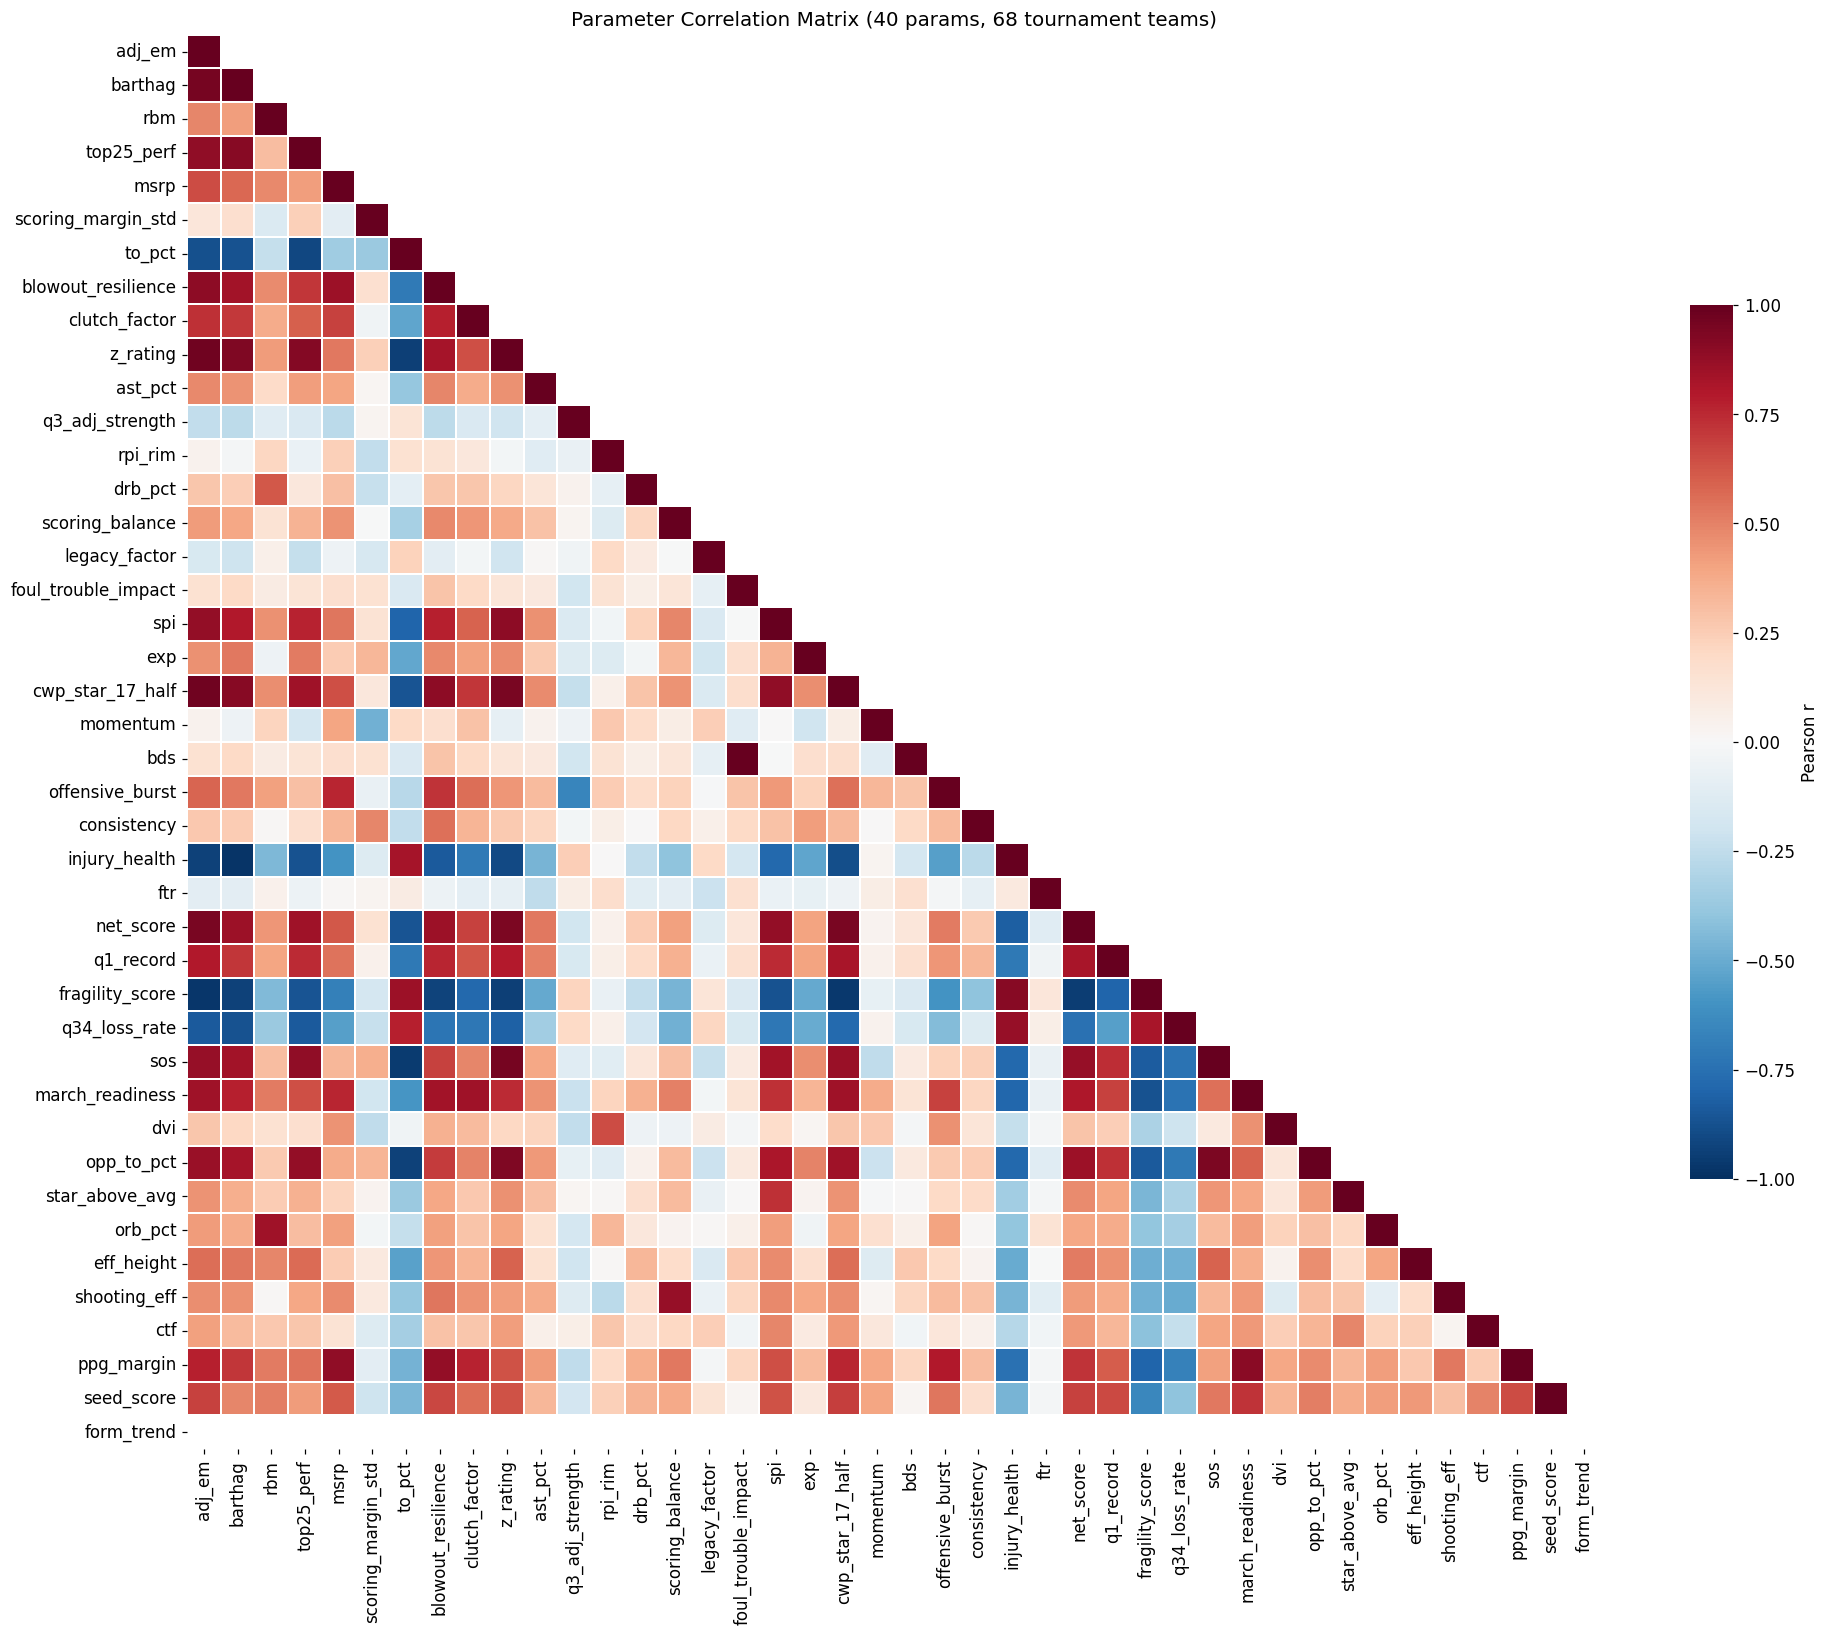

ValueError: The condensed distance matrix must contain only finite values.

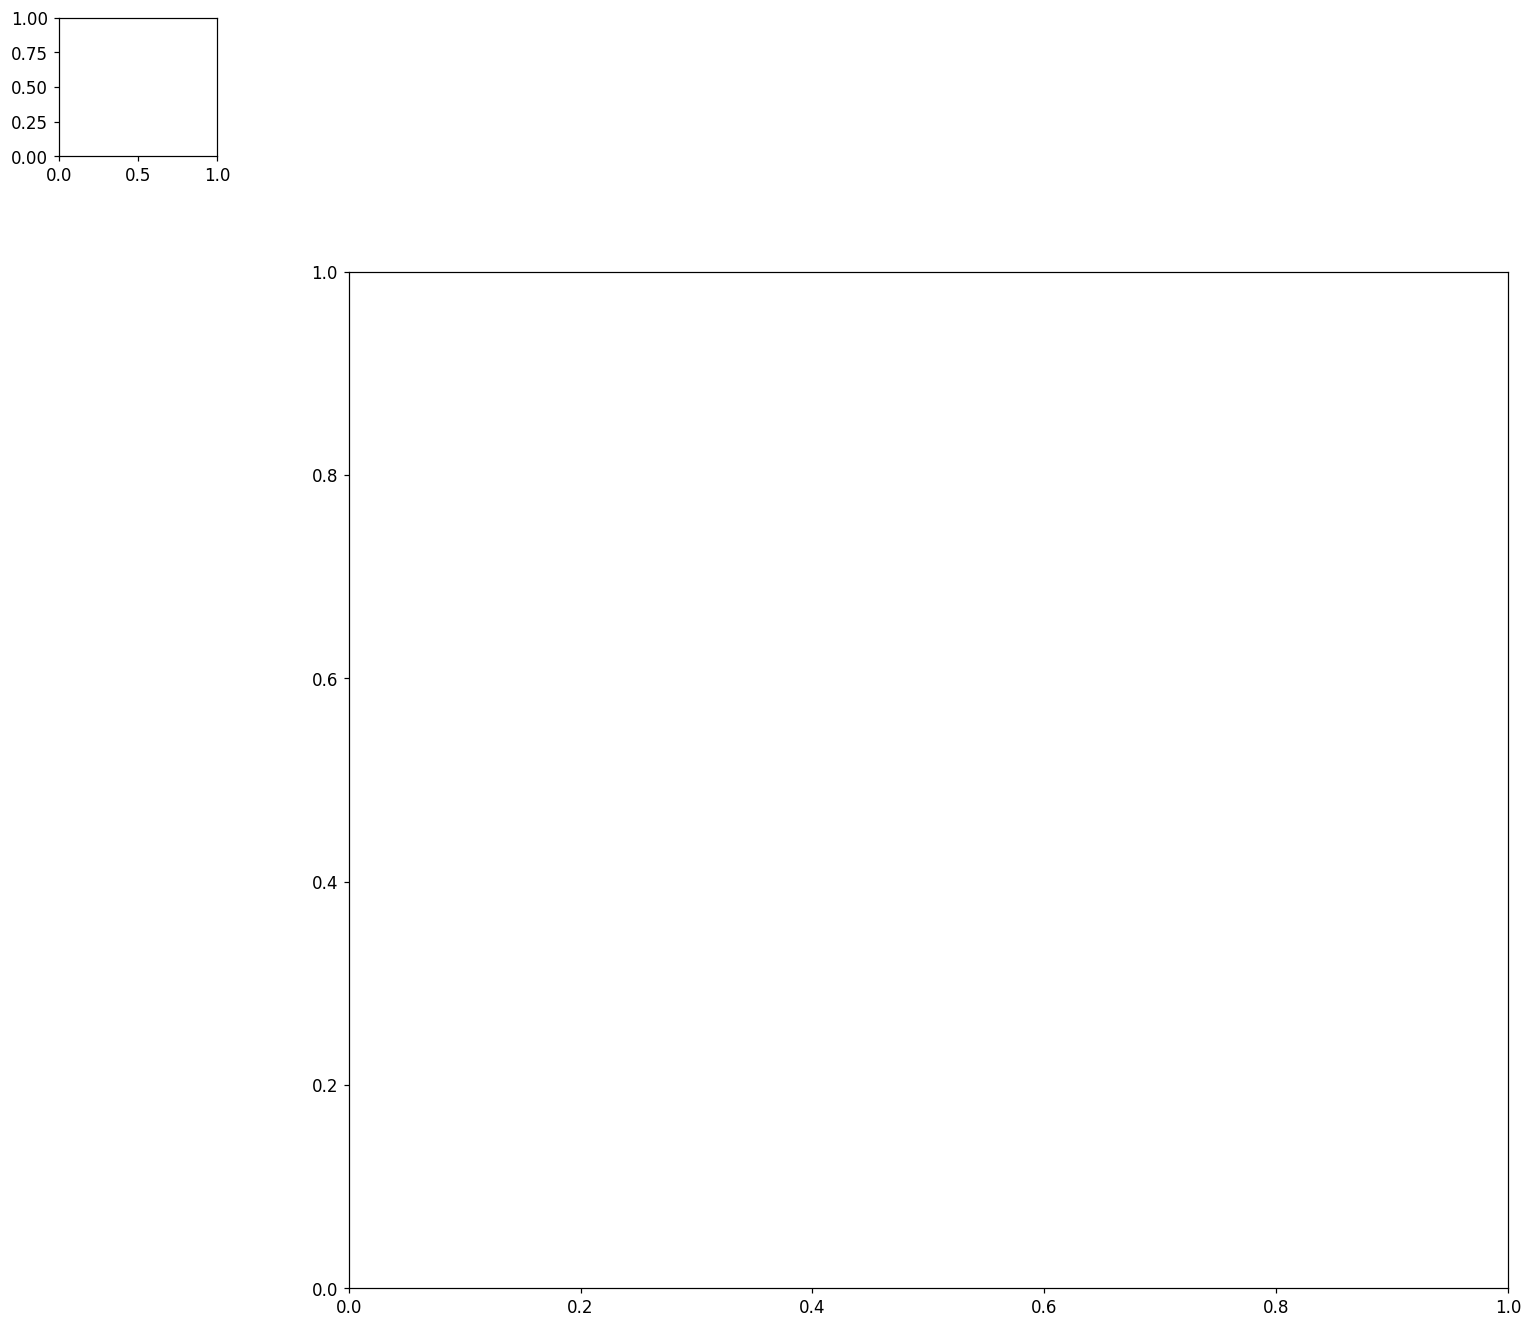

In [2]:
corr = param_df.corr()

mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(18, 15))
sns.heatmap(
    corr, mask=mask, cmap='RdBu_r', center=0,
    vmin=-1, vmax=1, annot=False,
    square=True, linewidths=0.3,
    cbar_kws={'shrink': 0.6, 'label': 'Pearson r'},
    ax=ax
)
ax.set_title('Parameter Correlation Matrix (40 params, 68 tournament teams)')
plt.tight_layout()
plt.show()

# Clustered version
g = sns.clustermap(
    corr, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    figsize=(17, 15), linewidths=0.2,
    dendrogram_ratio=0.12,
    cbar_kws={'label': 'Pearson r'},
)
g.fig.suptitle('Hierarchically Clustered Correlation Matrix', y=1.01)
plt.show()

# Flag pairs with |r| > 0.7
high_corr = []
for i in range(len(corr)):
    for j in range(i+1, len(corr)):
        r = corr.iloc[i, j]
        if abs(r) > 0.7:
            high_corr.append((corr.index[i], corr.columns[j], round(r, 3)))

high_corr.sort(key=lambda x: abs(x[2]), reverse=True)
print(f'\nHighly correlated pairs (|r| > 0.7): {len(high_corr)}')
for a, b, r in high_corr:
    w_a = CORE_WEIGHTS.get(a, 0)
    w_b = CORE_WEIGHTS.get(b, 0)
    print(f'  {a:<22} x {b:<22}  r={r:+.3f}  combined_weight={w_a+w_b:.3f}')

---
## Section 2: Weight Sensitivity Waterfall

Which parameters matter most when perturbed? Run sensitivity analysis from the optimizer.

In [ ]:
from src.weight_optimizer import (
    _build_eval_games, _evaluate_weights,
    stage2_sensitivity, _safe
)

kb = pd.read_csv('../archive-3/KenPom Barttorvik.csv')
tm = pd.read_csv('../archive-3/Tournament Matchups.csv')
games = _build_eval_games(kb, tm)

baseline_acc = _evaluate_weights(CORE_WEIGHTS, games, PARAM_KEYS)
print(f'Historical games: {len(games)}')
print(f'Baseline accuracy (CORE_WEIGHTS): {baseline_acc:.4f} ({baseline_acc*100:.1f}%)')

sensitivities = stage2_sensitivity(games, PARAM_KEYS, CORE_WEIGHTS)

Historical games: 1070
Baseline accuracy (CORE_WEIGHTS): 0.7290 (72.9%)

  STAGE 2: Sensitivity Analysis [NO WTH]
  Base accuracy: 0.7290

  Parameter                  Sensitivity     Best Δ    Direction
  ───────────────────────── ──────────── ────────── ────────────
  to_pct                         -0.561%     0.561%  ↓ -25%
  top25_perf                     +0.467%     0.467%  ↑ +50%
  legacy_factor                  +0.374%     0.374%  ↑ +50%
  ast_pct                        +0.374%     0.374%  ↓ -25%
  rbm                            +0.280%     0.280%  ↑ +25%
  cwp_star_17_half               +0.280%     0.280%  ↓ -50%
  momentum                       +0.280%     0.280%  ↓ -50%
  clutch_factor                  +0.187%     0.187%  ↓ -25%
  barthag                        +0.187%     0.187%  ↑ +50%
  z_rating                       -0.187%     0.187%  ↓ -25%
  scoring_balance                +0.187%     0.187%  ↓ -25%
  exp                            -0.187%     0.187%  ↑ +50%
  q3_adj_st

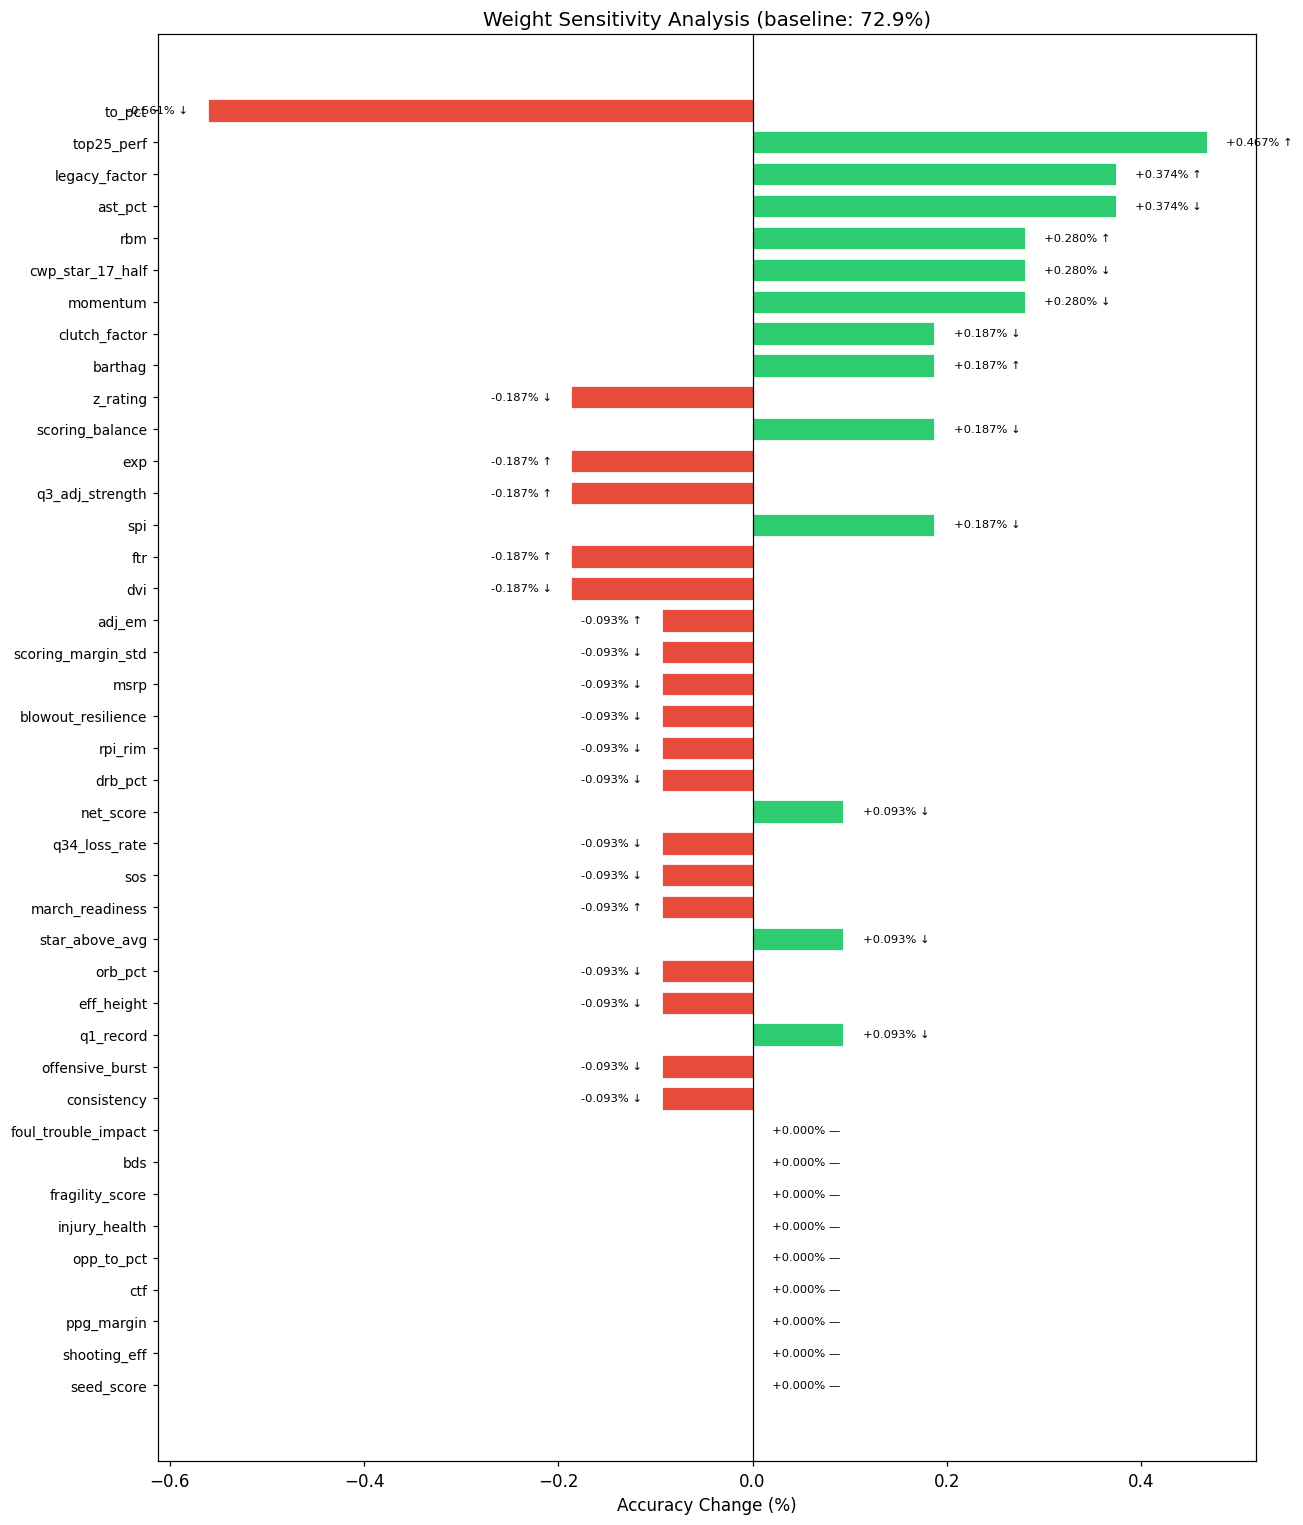

In [ ]:
params = [s[0] for s in sensitivities]
sens_vals = [s[1] * 100 for s in sensitivities]
directions = [s[2] for s in sensitivities]
colors = ['#2ecc71' if v > 0 else '#e74c3c' if v < 0 else '#95a5a6' for v in sens_vals]

fig, ax = plt.subplots(figsize=(12, 14))
y_pos = np.arange(len(params))
bars = ax.barh(y_pos, sens_vals, color=colors, height=0.7, edgecolor='white', linewidth=0.5)
ax.set_yticks(y_pos)
ax.set_yticklabels(params, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Accuracy Change (%)')
ax.set_title(f'Weight Sensitivity Analysis (baseline: {baseline_acc*100:.1f}%)')
ax.axvline(x=0, color='black', linewidth=0.8)

for i, (bar, val, d) in enumerate(zip(bars, sens_vals, directions)):
    arrow = '\u2191' if d > 0 else '\u2193' if d < 0 else '\u2014'
    label = f'{val:+.3f}% {arrow}'
    x_pos = bar.get_width()
    offset = 0.02 if x_pos >= 0 else -0.02
    ha = 'left' if x_pos >= 0 else 'right'
    ax.text(x_pos + offset, i, label, va='center', ha=ha, fontsize=7.5)

plt.tight_layout()
plt.show()

---
## Section 3: SHAP Feature Importance (XGBoost)

Which features does the XGBoost model (Phase 1B) actually rely on? Compare to our weight assignments.

In [ ]:
import shap
import xgboost as xgb
from src.xgboost_model import (
    prepare_historical_features, ML_FEATURE_KEYS, train_xgboost
)

kb_hist = pd.read_csv('../archive-3/KenPom Barttorvik.csv')
tm_hist = pd.read_csv('../archive-3/Tournament Matchups.csv')
X_train, y_train = prepare_historical_features(kb_hist, tm_hist)
print(f'Training samples: {len(X_train)}')

model, _ = train_xgboost(X_train, y_train)

# build_ml_features produces (a_val, b_val, diff) triplets per key
feature_names = []
for k in ML_FEATURE_KEYS:
    feature_names.extend([f'{k}_a', f'{k}_b', f'd_{k}'])

# Truncate if mismatch (safety)
n_feats = X_train.shape[1]
feature_names = feature_names[:n_feats]
if len(feature_names) < n_feats:
    feature_names += [f'feat_{i}' for i in range(len(feature_names), n_feats)]

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_train)

print(f'SHAP values shape: {shap_values.shape}')
print(f'Features: {len(feature_names)}')

Training samples: 1888
SHAP values shape: (1888, 78)
Features: 78


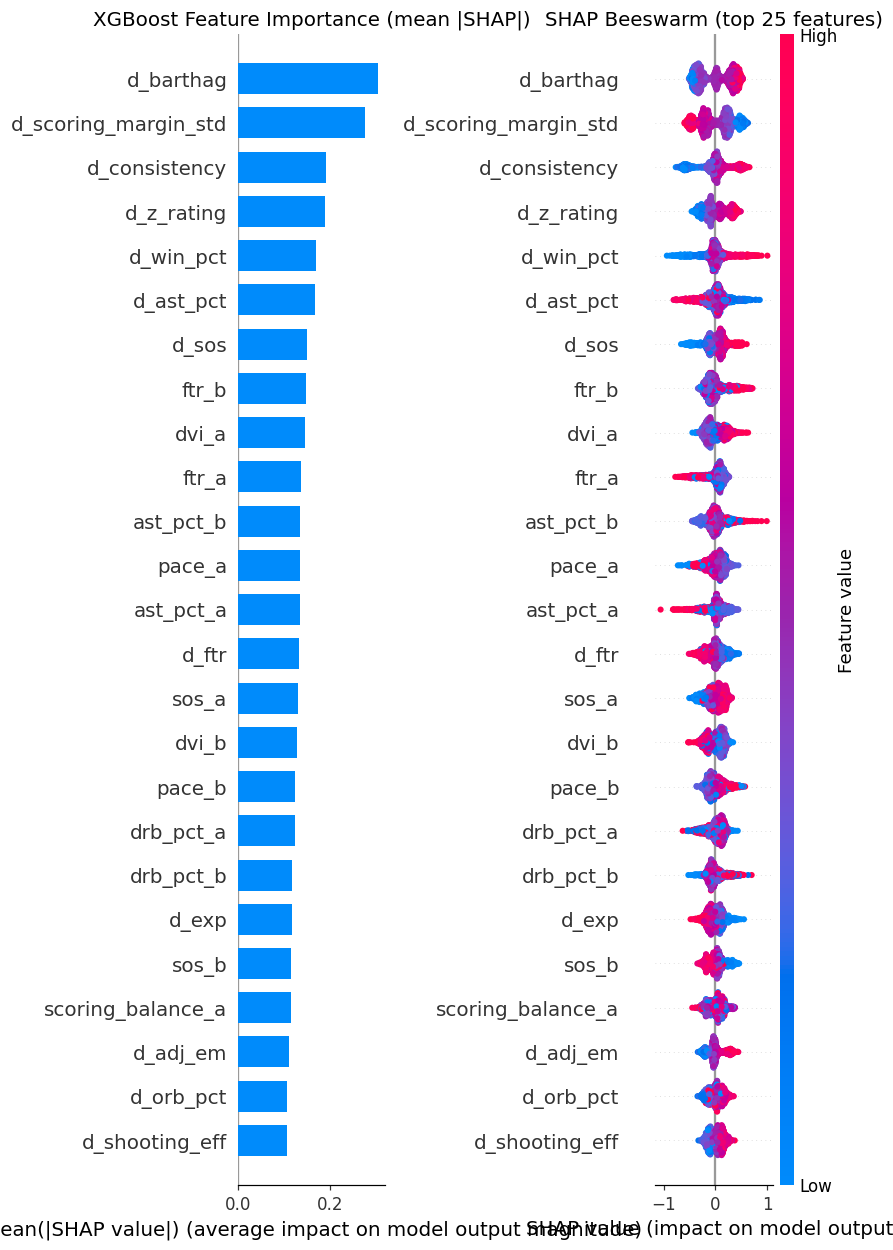

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# Bar plot (mean |SHAP|)
plt.sca(axes[0])
shap.summary_plot(
    shap_values, X_train,
    feature_names=feature_names,
    plot_type='bar', show=False,
    max_display=25
)
axes[0].set_title('XGBoost Feature Importance (mean |SHAP|)')

# Beeswarm plot
plt.sca(axes[1])
shap.summary_plot(
    shap_values, X_train,
    feature_names=feature_names,
    show=False,
    max_display=25
)
axes[1].set_title('SHAP Beeswarm (top 25 features)')

plt.tight_layout()
plt.show()

In [ ]:
# Compare SHAP ranking vs Weight ranking
mean_shap = np.abs(shap_values).mean(axis=0)
shap_rank = pd.Series(mean_shap, index=feature_names).sort_values(ascending=False)

# Aggregate SHAP by base parameter (sum across _a, _b, d_ variants)
param_shap = {}
for k in ML_FEATURE_KEYS:
    total = 0.0
    for suffix in [f'{k}_a', f'{k}_b', f'd_{k}']:
        if suffix in shap_rank.index:
            total += shap_rank[suffix]
    param_shap[k] = total
param_shap_series = pd.Series(param_shap).sort_values(ascending=False)

weight_rank = pd.Series(CORE_WEIGHTS).sort_values(ascending=False)

print('SHAP Top 10 (aggregated by parameter -- what XGBoost uses):')
for i, (feat, val) in enumerate(param_shap_series.head(10).items(), 1):
    w = CORE_WEIGHTS.get(feat, 0)
    print(f'  {i:>2}. {feat:<25} SHAP={val:.4f}  weight={w:.4f}')

print('\nWeight Top 10 (what we assigned):')
for i, (feat, val) in enumerate(weight_rank.head(10).items(), 1):
    s = param_shap.get(feat, 0)
    print(f'  {i:>2}. {feat:<25} weight={val:.4f}  SHAP={s:.4f}')

SHAP Top 10 (aggregated by parameter -- what XGBoost uses):
   1. barthag                   SHAP=0.4744  weight=0.0474
   2. ast_pct                   SHAP=0.4356  weight=0.0419
   3. ftr                       SHAP=0.4146  weight=0.0083
   4. sos                       SHAP=0.3938  weight=0.0038
   5. z_rating                  SHAP=0.3793  weight=0.0425
   6. dvi                       SHAP=0.3387  weight=0.0032
   7. win_pct                   SHAP=0.3218  weight=0.0000
   8. scoring_margin_std        SHAP=0.3081  weight=0.0738
   9. pace                      SHAP=0.3022  weight=0.0000
  10. orb_pct                   SHAP=0.2941  weight=0.0023

Weight Top 10 (what we assigned):
   1. adj_em                    weight=0.1209  SHAP=0.1842
   2. to_pct                    weight=0.0819  SHAP=0.1729
   3. msrp                      weight=0.0763  SHAP=0.0000
   4. scoring_margin_std        weight=0.0738  SHAP=0.3081
   5. rbm                       weight=0.0678  SHAP=0.1797
   6. clutch_factor 

---
## Section 4: Calibration Curve (Probability Reliability)

When we predict 70%, does the team actually win ~70% of the time?

Games: 1070
Accuracy: 0.7290 (72.9%)
Brier Score: 0.1880 (lower = better, perfect = 0)


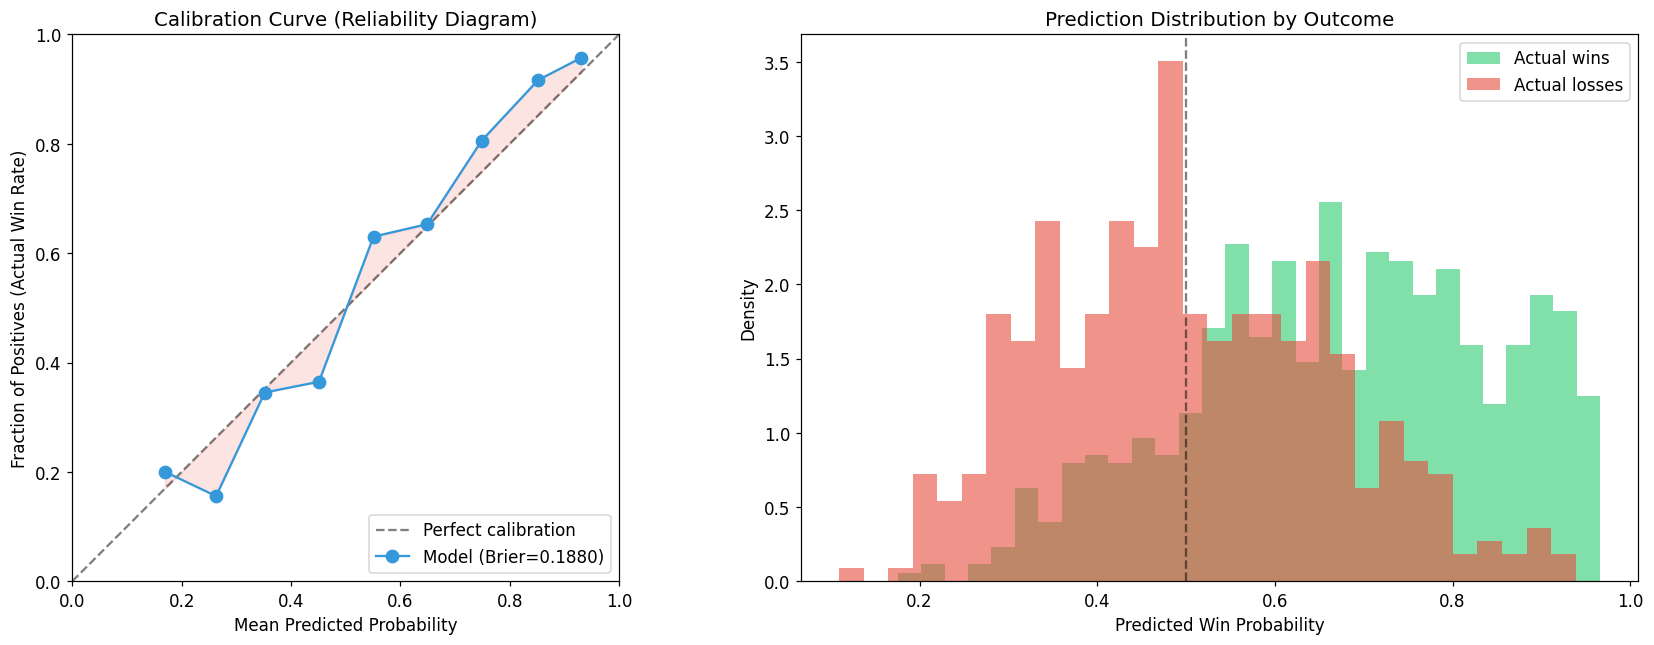

In [ ]:
from sklearn.calibration import calibration_curve
from src.weight_optimizer import _normalize_param_values, _predict_winner

# Get predictions for all historical games
all_params = [g[0] for g in games] + [g[1] for g in games]
normalized = _normalize_param_values(all_params, PARAM_KEYS)

n_games = len(games)
norm_a = normalized[:n_games]
norm_b = normalized[n_games:]

y_true = []
y_pred = []
for i, (_, _, a_won, _year) in enumerate(games):
    prob_a = _predict_winner(norm_a[i], norm_b[i], CORE_WEIGHTS)
    y_pred.append(prob_a)
    y_true.append(int(a_won))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Brier score
brier = np.mean((y_pred - y_true) ** 2)
accuracy = np.mean((y_pred > 0.5) == y_true)
print(f'Games: {n_games}')
print(f'Accuracy: {accuracy:.4f} ({accuracy*100:.1f}%)')
print(f'Brier Score: {brier:.4f} (lower = better, perfect = 0)')

# Calibration curve
prob_true, prob_pred = calibration_curve(y_true, y_pred, n_bins=10, strategy='uniform')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Reliability diagram
ax = axes[0]
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect calibration')
ax.plot(prob_pred, prob_true, 'o-', color='#3498db', markersize=8, label=f'Model (Brier={brier:.4f})')
ax.fill_between(prob_pred, prob_true, prob_pred, alpha=0.15, color='#e74c3c')
ax.set_xlabel('Mean Predicted Probability')
ax.set_ylabel('Fraction of Positives (Actual Win Rate)')
ax.set_title('Calibration Curve (Reliability Diagram)')
ax.legend(loc='lower right')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_aspect('equal')

# Prediction distribution
ax2 = axes[1]
ax2.hist(y_pred[y_true == 1], bins=30, alpha=0.6, color='#2ecc71', label='Actual wins', density=True)
ax2.hist(y_pred[y_true == 0], bins=30, alpha=0.6, color='#e74c3c', label='Actual losses', density=True)
ax2.set_xlabel('Predicted Win Probability')
ax2.set_ylabel('Density')
ax2.set_title('Prediction Distribution by Outcome')
ax2.legend()
ax2.axvline(x=0.5, color='black', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

---
## Section 5: Parameter Distributions by Seed Tier

For each parameter, do higher seeds actually score better? Find weak/inverted signals.

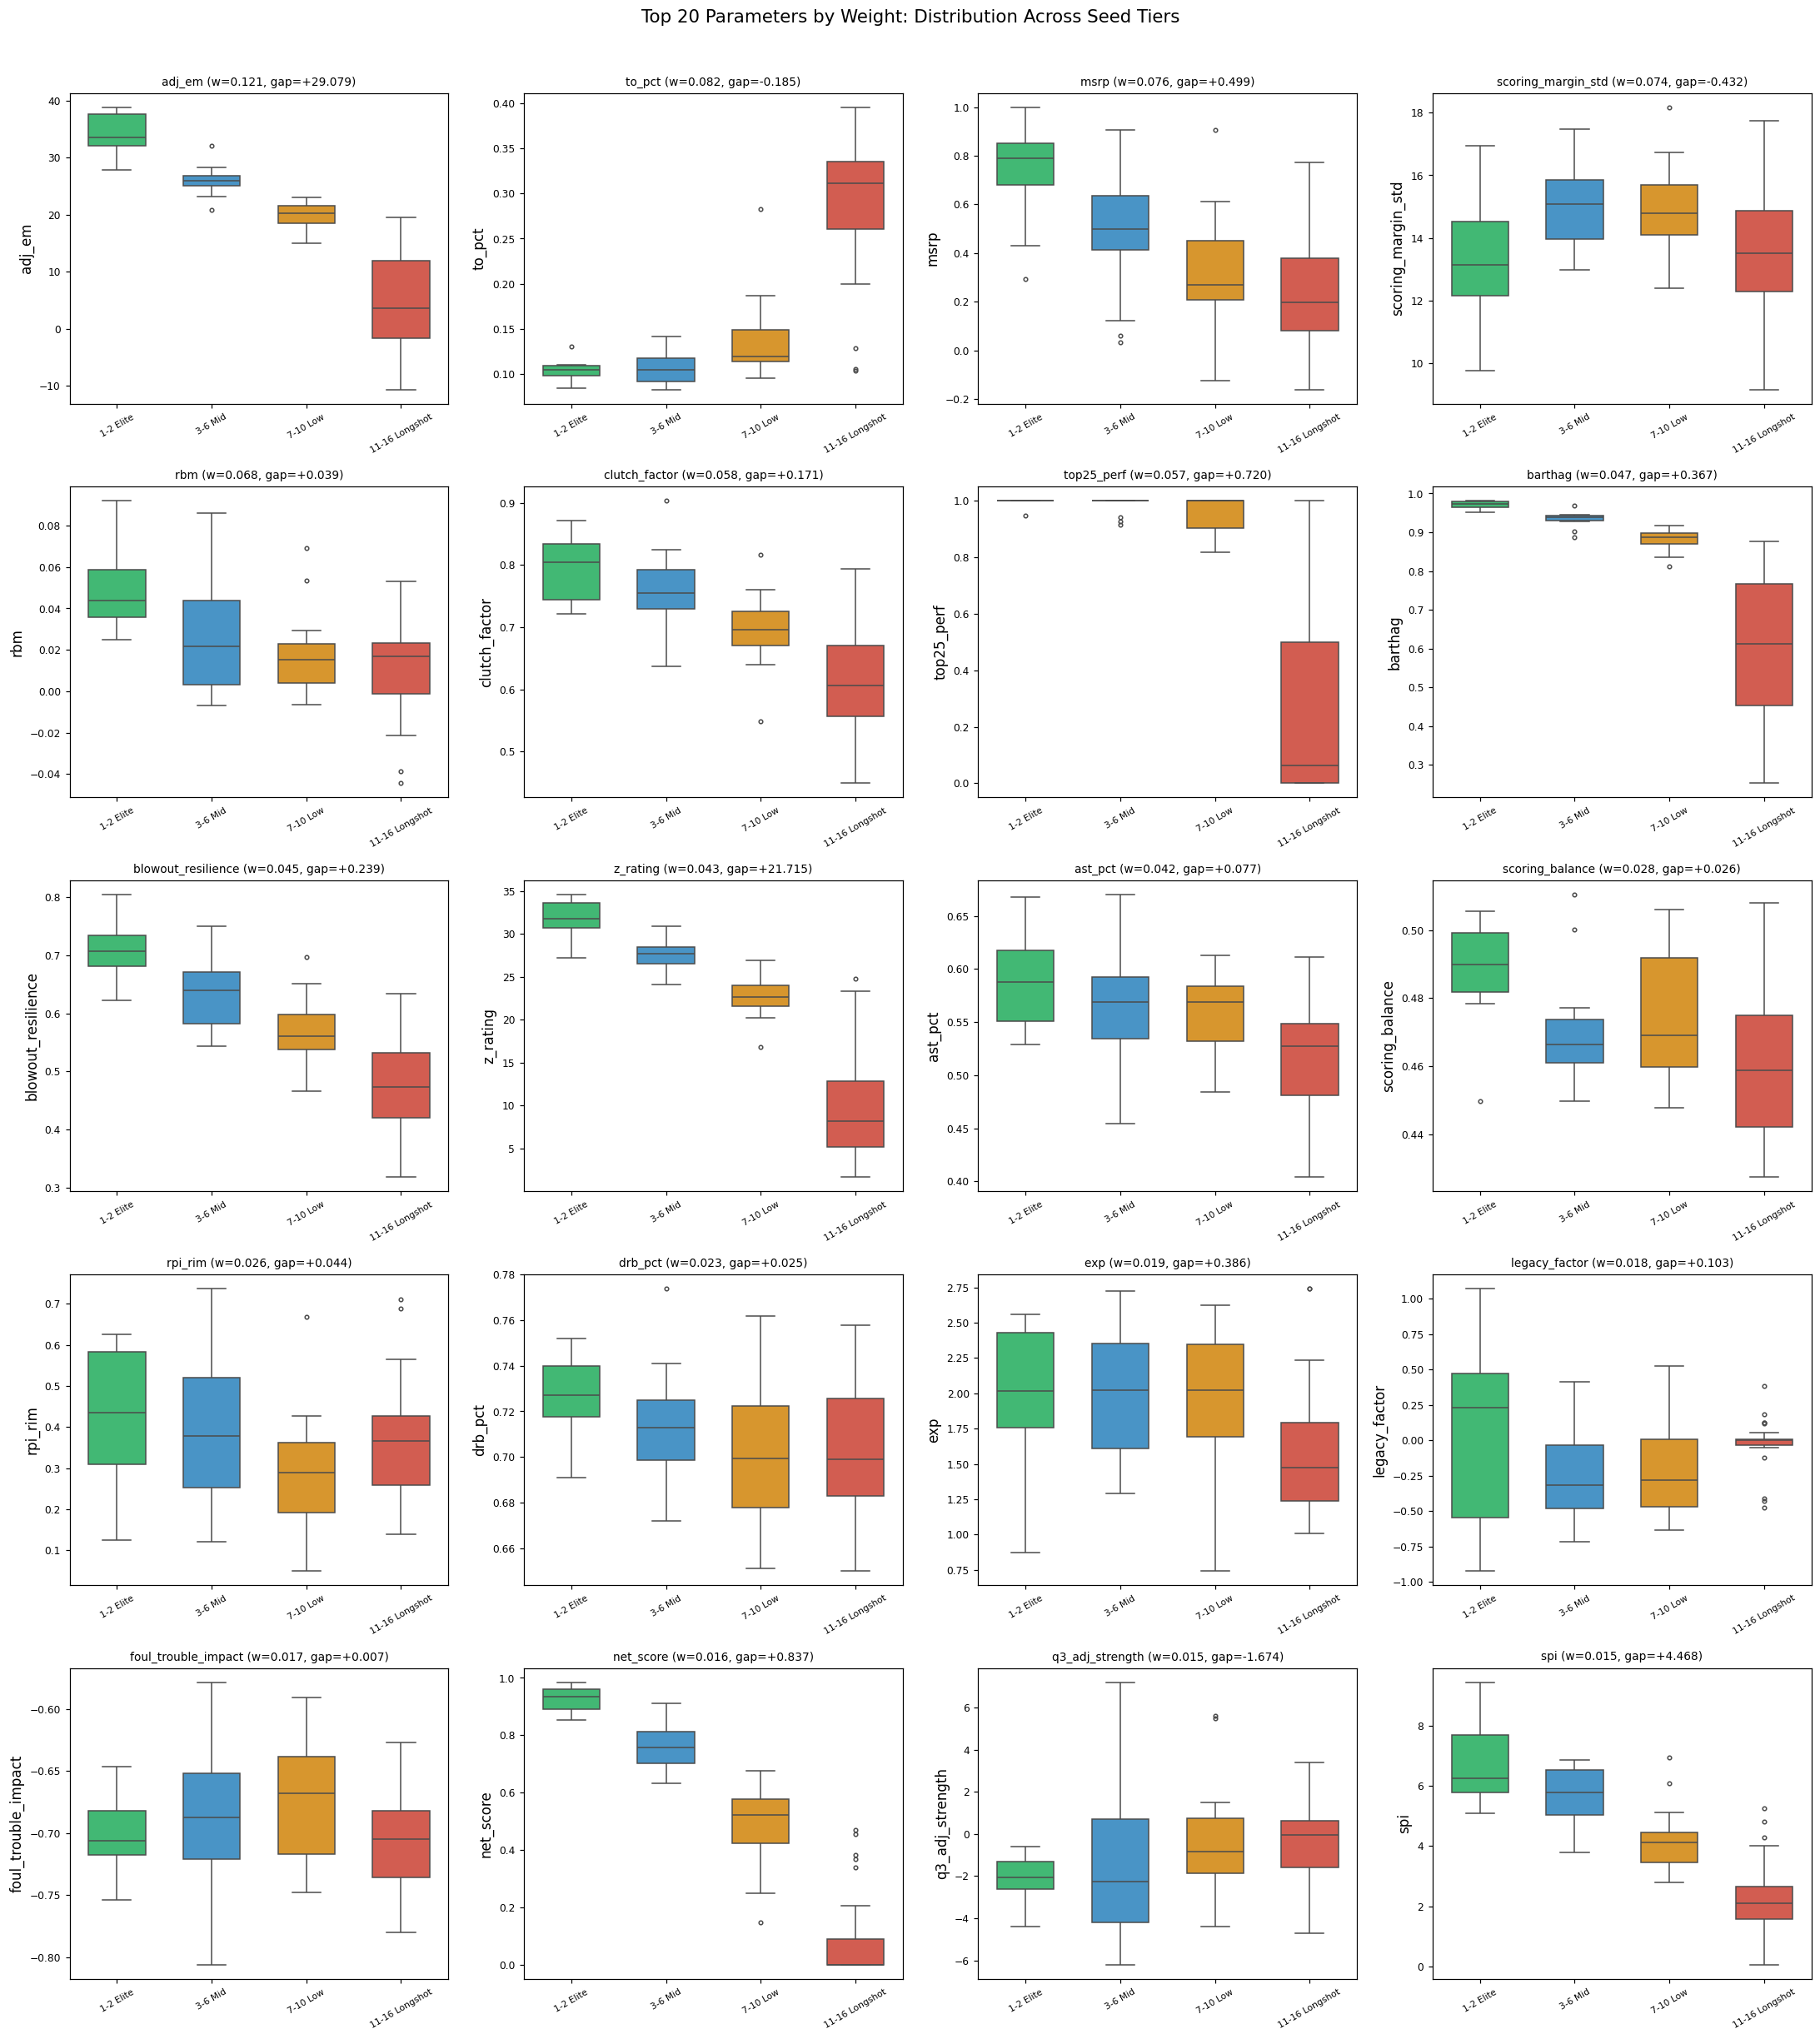

In [ ]:
def seed_tier(seed):
    if seed <= 2: return '1-2 Elite'
    if seed <= 6: return '3-6 Mid'
    if seed <= 10: return '7-10 Low'
    return '11-16 Longshot'

df['tier'] = df['seed'].apply(seed_tier)
tier_order = ['1-2 Elite', '3-6 Mid', '7-10 Low', '11-16 Longshot']

top_params = sorted(PARAM_KEYS, key=lambda k: CORE_WEIGHTS[k], reverse=True)[:20]

n_cols = 4
n_rows = 5
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 22))
axes_flat = axes.flatten()

palette = {'1-2 Elite': '#2ecc71', '3-6 Mid': '#3498db', '7-10 Low': '#f39c12', '11-16 Longshot': '#e74c3c'}

for idx, param in enumerate(top_params):
    ax = axes_flat[idx]
    weight = CORE_WEIGHTS[param]
    
    sns.boxplot(
        data=df, x='tier', y=param, order=tier_order,
        palette=palette, ax=ax, width=0.6,
        flierprops={'markersize': 3}
    )
    
    elite_mean = df[df['tier'] == '1-2 Elite'][param].mean()
    longshot_mean = df[df['tier'] == '11-16 Longshot'][param].mean()
    gap = elite_mean - longshot_mean
    
    ax.set_title(f'{param} (w={weight:.3f}, gap={gap:+.3f})', fontsize=9)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30, labelsize=7)
    ax.tick_params(axis='y', labelsize=8)

plt.suptitle('Top 20 Parameters by Weight: Distribution Across Seed Tiers', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
# Full separation report
print('Parameter Separation Report (Elite mean - Longshot mean):')
print(f'{"Parameter":<25} {"Elite":>8} {"Longshot":>10} {"Gap":>8} {"Weight":>8} {"Signal":>8}')
print('-' * 75)
for param in sorted(PARAM_KEYS, key=lambda k: CORE_WEIGHTS[k], reverse=True):
    e = df[df['tier'] == '1-2 Elite'][param].mean()
    l = df[df['tier'] == '11-16 Longshot'][param].mean()
    gap = e - l
    w = CORE_WEIGHTS[param]
    signal = 'GOOD' if gap > 0.15 else 'WEAK' if gap > 0.05 else 'POOR' if gap > -0.05 else 'INVERTED'
    print(f'{param:<25} {e:>8.3f} {l:>10.3f} {gap:>+8.3f} {w:>8.4f} {signal:>8}')

Parameter Separation Report (Elite mean - Longshot mean):
Parameter                    Elite   Longshot      Gap   Weight   Signal
---------------------------------------------------------------------------
adj_em                      34.107      5.028  +29.079   0.1209     GOOD
to_pct                       0.104      0.290   -0.185   0.0819 INVERTED
msrp                         0.729      0.230   +0.499   0.0763     GOOD
scoring_margin_std          13.198     13.630   -0.432   0.0738 INVERTED
rbm                          0.050      0.011   +0.039   0.0678     POOR
clutch_factor                0.793      0.622   +0.171   0.0581     GOOD
top25_perf                   0.993      0.274   +0.720   0.0573     GOOD
barthag                      0.971      0.603   +0.367   0.0474     GOOD
blowout_resilience           0.711      0.472   +0.239   0.0448     GOOD
z_rating                    31.696      9.981  +21.715   0.0425     GOOD
ast_pct                      0.591      0.514   +0.077   0.0419

---
## Section 6: ORIGINAL vs CORE Weight Comparison

Side-by-side comparison of hand-tuned vs optimizer-derived weights.

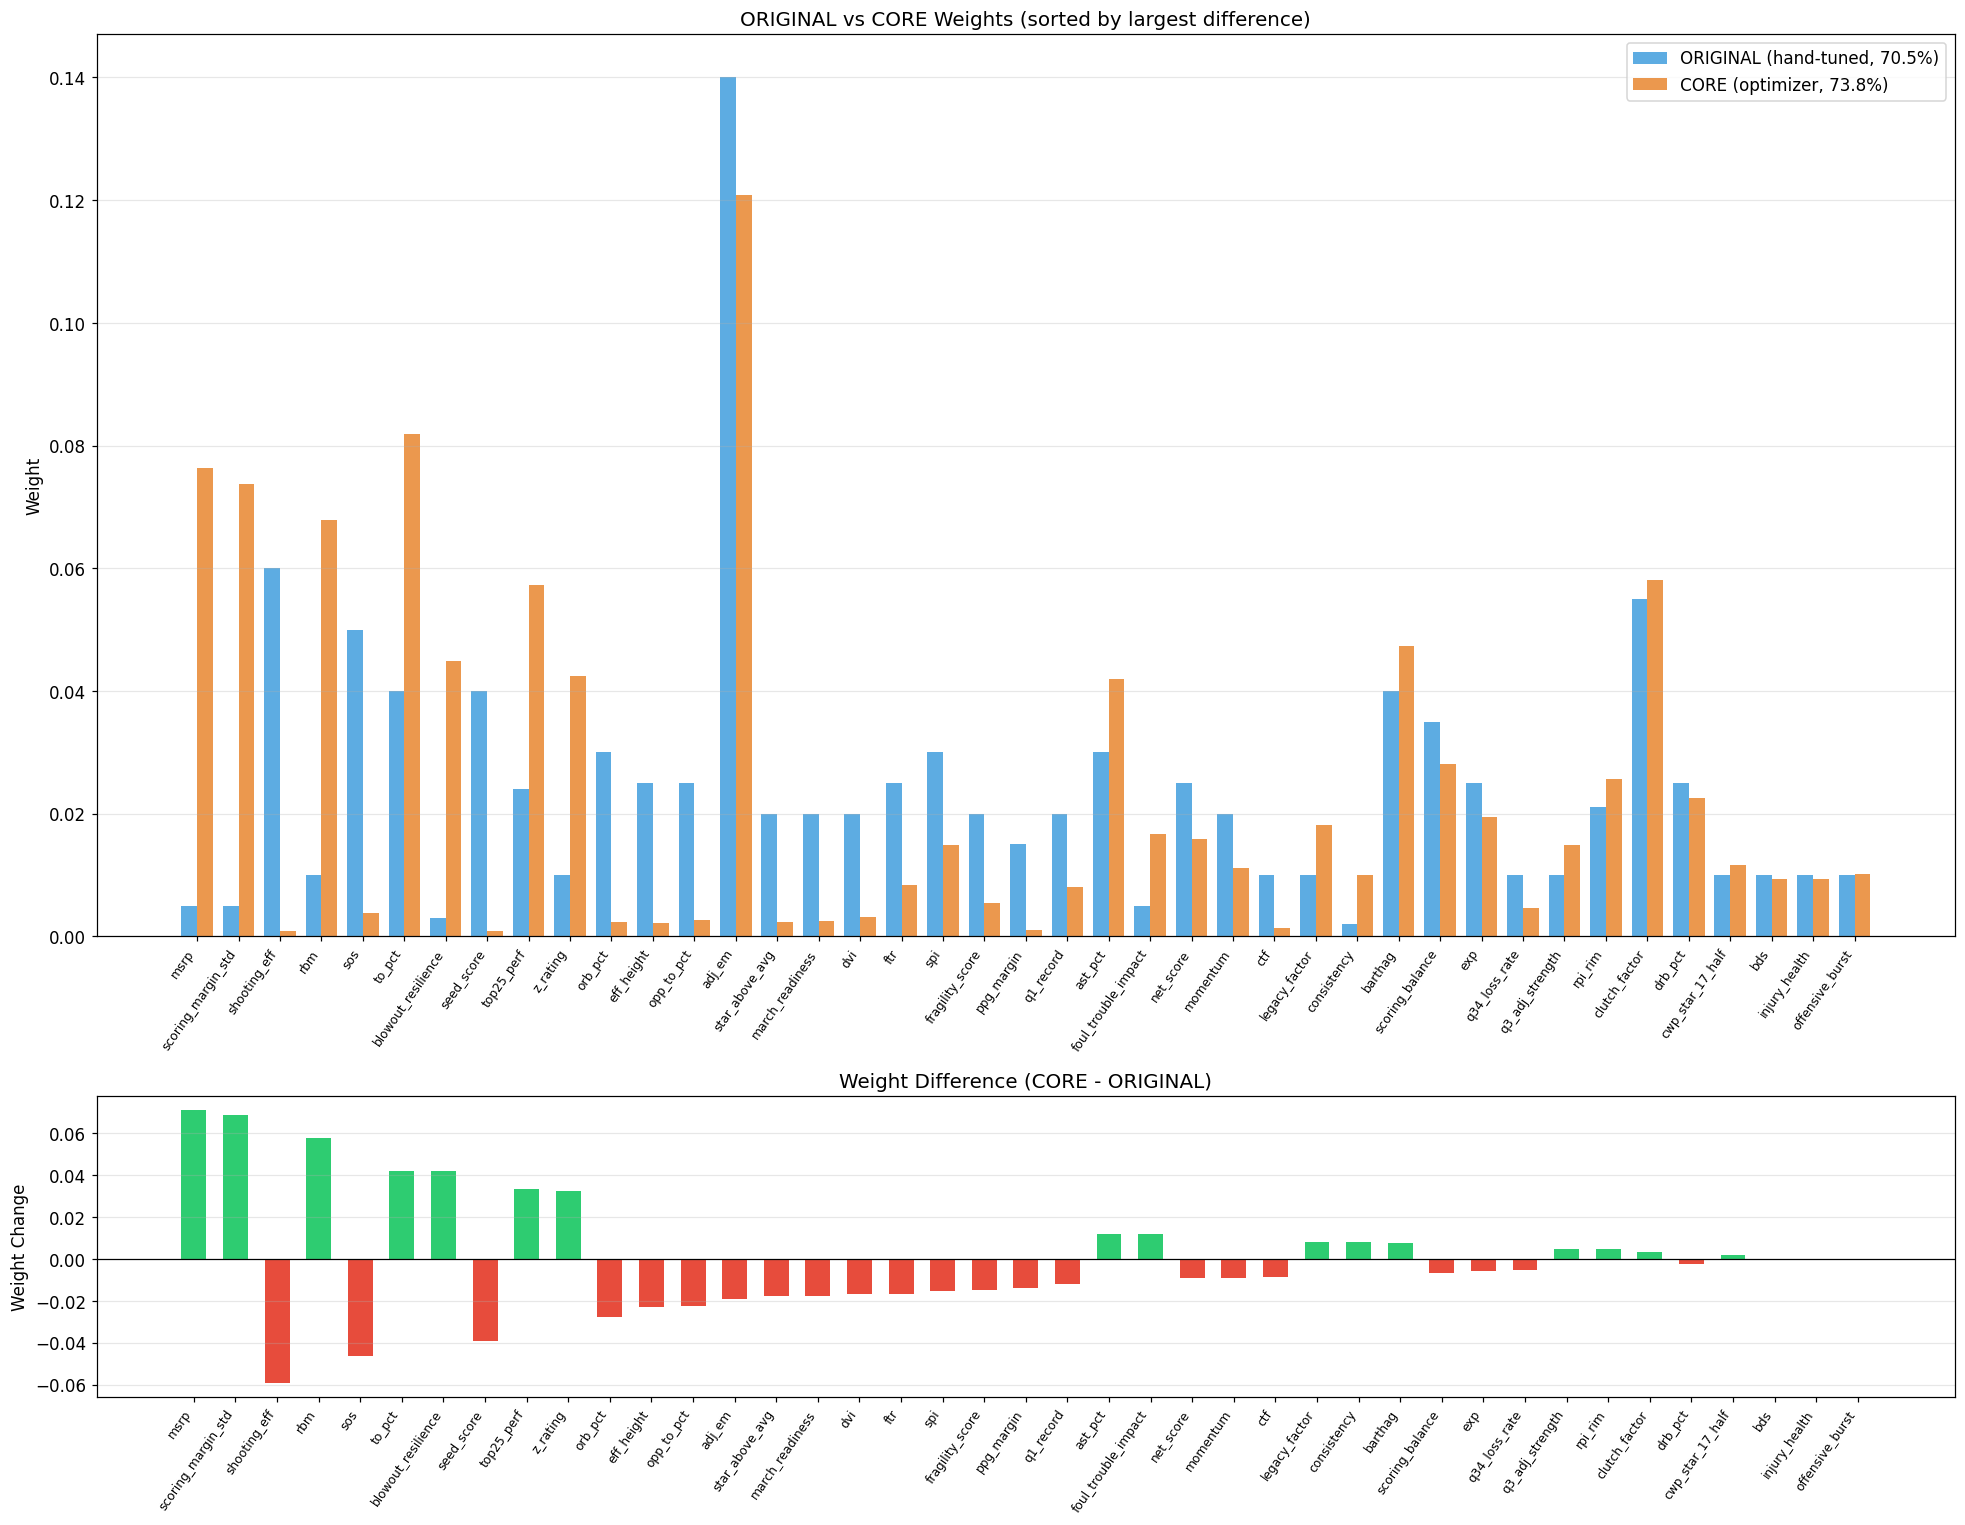

In [ ]:
params_sorted = sorted(PARAM_KEYS, key=lambda k: abs(CORE_WEIGHTS[k] - ORIGINAL_WEIGHTS[k]), reverse=True)

orig_vals = [ORIGINAL_WEIGHTS[k] for k in params_sorted]
core_vals = [CORE_WEIGHTS[k] for k in params_sorted]

x = np.arange(len(params_sorted))
width = 0.38

fig, axes = plt.subplots(2, 1, figsize=(18, 14), gridspec_kw={'height_ratios': [3, 1]})

ax = axes[0]
bars1 = ax.bar(x - width/2, orig_vals, width, label='ORIGINAL (hand-tuned, 70.5%)', color='#3498db', alpha=0.8)
bars2 = ax.bar(x + width/2, core_vals, width, label='CORE (optimizer, 73.8%)', color='#e67e22', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(params_sorted, rotation=55, ha='right', fontsize=8)
ax.set_ylabel('Weight')
ax.set_title('ORIGINAL vs CORE Weights (sorted by largest difference)')
ax.legend(loc='upper right')
ax.grid(axis='y', alpha=0.3)

# Difference subplot
ax2 = axes[1]
diffs = [CORE_WEIGHTS[k] - ORIGINAL_WEIGHTS[k] for k in params_sorted]
colors = ['#2ecc71' if d > 0 else '#e74c3c' for d in diffs]
ax2.bar(x, diffs, color=colors, width=0.6)
ax2.set_xticks(x)
ax2.set_xticklabels(params_sorted, rotation=55, ha='right', fontsize=8)
ax2.set_ylabel('Weight Change')
ax2.set_title('Weight Difference (CORE - ORIGINAL)')
ax2.axhline(y=0, color='black', linewidth=0.8)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Accuracy comparison + top changes
orig_acc = _evaluate_weights(ORIGINAL_WEIGHTS, games, PARAM_KEYS)
core_acc = _evaluate_weights(CORE_WEIGHTS, games, PARAM_KEYS)
print(f'Historical accuracy:')
print(f'  ORIGINAL_WEIGHTS: {orig_acc*100:.1f}%')
print(f'  CORE_WEIGHTS:     {core_acc*100:.1f}%')
print(f'  Improvement:      {(core_acc-orig_acc)*100:+.1f}%')

print(f'\nTop 5 largest weight increases (optimizer wants MORE):')
for k in sorted(PARAM_KEYS, key=lambda k: CORE_WEIGHTS[k] - ORIGINAL_WEIGHTS[k], reverse=True)[:5]:
    print(f'  {k:<25} {ORIGINAL_WEIGHTS[k]:.4f} -> {CORE_WEIGHTS[k]:.4f}  ({(CORE_WEIGHTS[k]-ORIGINAL_WEIGHTS[k])*100:+.2f}%)')

print(f'\nTop 5 largest weight decreases (optimizer wants LESS):')
for k in sorted(PARAM_KEYS, key=lambda k: CORE_WEIGHTS[k] - ORIGINAL_WEIGHTS[k])[:5]:
    print(f'  {k:<25} {ORIGINAL_WEIGHTS[k]:.4f} -> {CORE_WEIGHTS[k]:.4f}  ({(CORE_WEIGHTS[k]-ORIGINAL_WEIGHTS[k])*100:+.2f}%)')

Historical accuracy:
  ORIGINAL_WEIGHTS: 70.1%
  CORE_WEIGHTS:     72.9%
  Improvement:      +2.8%

Top 5 largest weight increases (optimizer wants MORE):
  msrp                      0.0050 -> 0.0763  (+7.13%)
  scoring_margin_std        0.0050 -> 0.0738  (+6.88%)
  rbm                       0.0100 -> 0.0678  (+5.78%)
  to_pct                    0.0400 -> 0.0819  (+4.19%)
  blowout_resilience        0.0030 -> 0.0448  (+4.18%)

Top 5 largest weight decreases (optimizer wants LESS):
  shooting_eff              0.0600 -> 0.0008  (-5.92%)
  sos                       0.0500 -> 0.0038  (-4.62%)
  seed_score                0.0400 -> 0.0008  (-3.92%)
  orb_pct                   0.0300 -> 0.0023  (-2.77%)
  eff_height                0.0250 -> 0.0021  (-2.29%)


---
## Section 7: Outlier Games / Scoring Consistency Analysis

Compute per-game scoring margin variance from real game logs. Find "wave" teams (high std dev = volatile, upset-prone) vs "flat" teams (low std dev = reliable, tournament-safe).

In [ ]:
import glob

log_dir = '../archive-3/game-logs/'
team_volatility = []

for fp in sorted(glob.glob(log_dir + '*.csv')):
    gdf = pd.read_csv(fp)
    if gdf.empty or 'score_t' not in gdf.columns:
        continue
    tname = gdf.iloc[0]['team']
    margins = gdf['score_t'].astype(float) - gdf['score_o'].astype(float)
    mean_m = margins.mean()
    std_m = margins.std()
    n_games = len(margins)
    outlier_hi = (margins > mean_m + 2 * std_m).sum()
    outlier_lo = (margins < mean_m - 2 * std_m).sum()
    worst_delta = (margins - mean_m).min()
    best_delta = (margins - mean_m).max()
    cv = std_m / abs(mean_m) if abs(mean_m) > 0.5 else float('inf')

    # Match to our team list for seed
    matched = [t for t in teams if t.name.lower().startswith(tname.lower()[:6])]
    seed = matched[0].seed if matched else 8
    tier = seed_tier(seed)

    team_volatility.append({
        'team': tname, 'seed': seed, 'tier': tier,
        'margin_mean': mean_m, 'margin_std': std_m,
        'games': n_games, 'outlier_hi': outlier_hi, 'outlier_lo': outlier_lo,
        'worst_delta': worst_delta, 'best_delta': best_delta, 'cv': cv,
    })

vol_df = pd.DataFrame(team_volatility).sort_values('margin_std')
print(f'Analyzed {len(vol_df)} teams from game logs')
vol_df.head()

Analyzed 68 teams from game logs


,team,seed,tier,margin_mean,margin_std,games,outlier_hi,outlier_lo,worst_delta,best_delta,cv
30,Miami (OH),7,7-10 Low,11.595656,9.158524,29,1,0,-15.595656,20.163102,0.789824
2,Arizona,1,1-2 Elite,15.903338,9.772118,34,0,1,-21.342484,14.788639,0.614470
8,Duke,1,1-2 Elite,16.322253,10.798438,34,0,0,-19.322253,18.101521,0.661578
40,Penn,14,11-16 Longshot,1.017960,11.248102,28,0,1,-29.840853,19.483810,11.049647
67,Wright State,14,11-16 Longshot,5.307389,11.295805,32,0,0,-21.590677,19.847623,2.128317


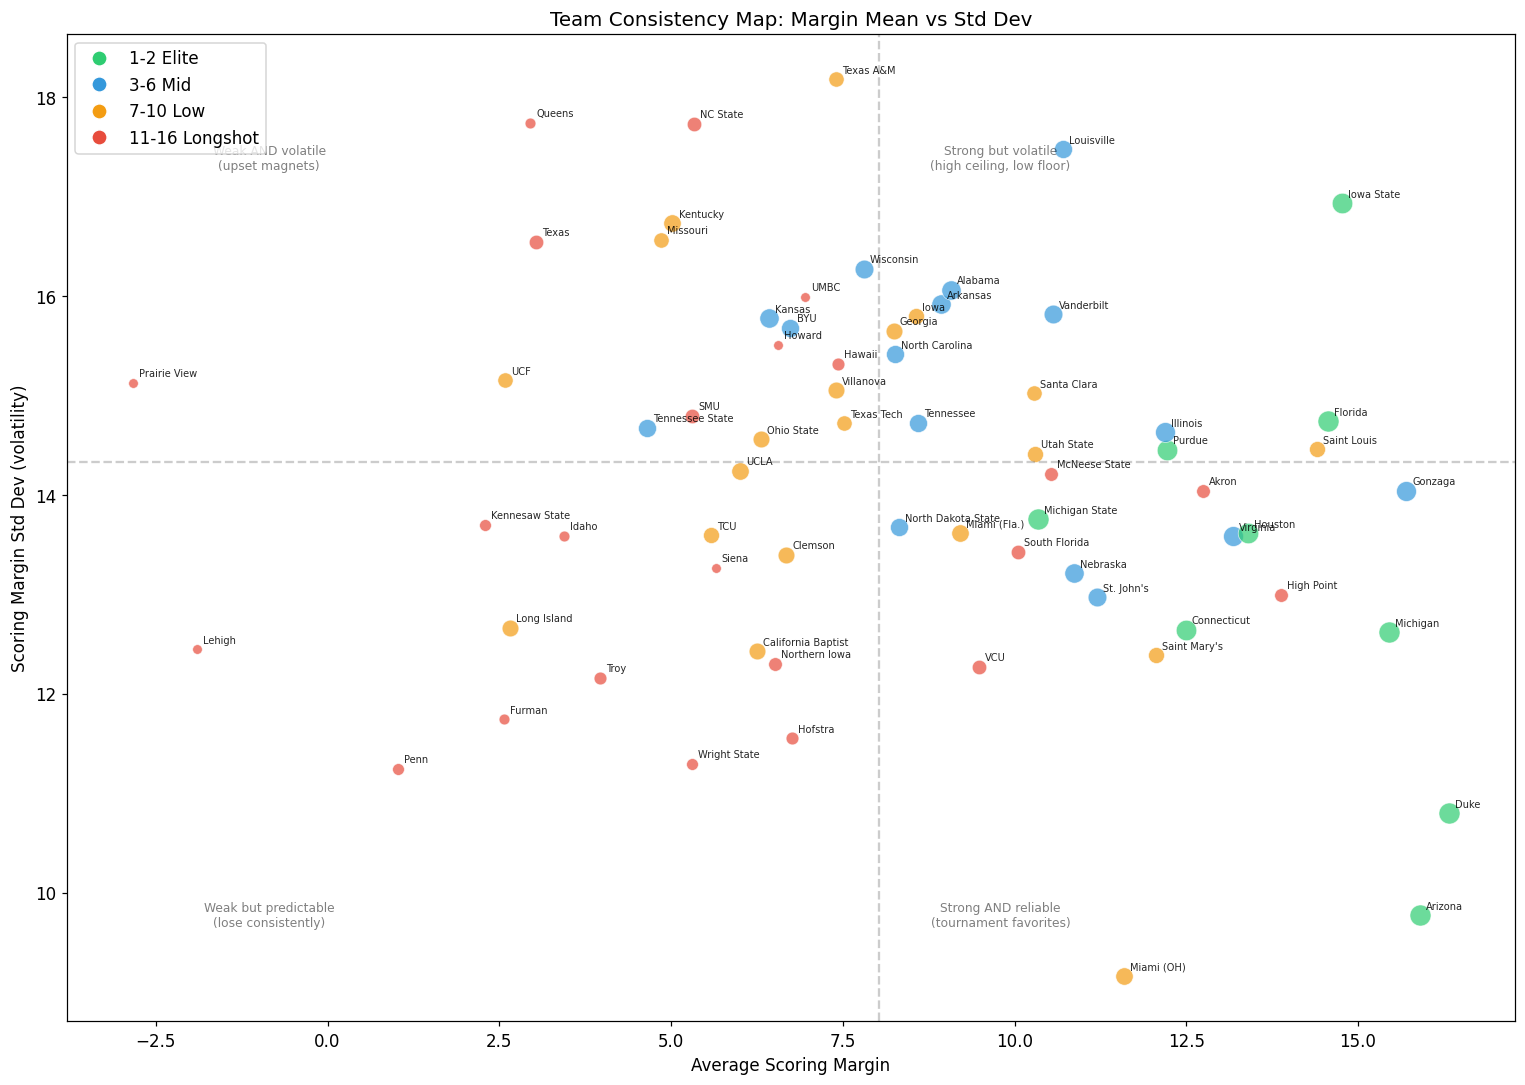

In [ ]:
# Scatter: mean margin (x) vs std dev (y) -- quadrant analysis
fig, ax = plt.subplots(figsize=(14, 10))
palette_v = {'1-2 Elite': '#2ecc71', '3-6 Mid': '#3498db', '7-10 Low': '#f39c12', '11-16 Longshot': '#e74c3c'}

for _, row in vol_df.iterrows():
    color = palette_v.get(row['tier'], 'gray')
    size = max(200 - row['seed'] * 10, 40)
    ax.scatter(row['margin_mean'], row['margin_std'], s=size, c=color,
               alpha=0.7, edgecolors='white', linewidth=0.5)
    ax.annotate(row['team'], (row['margin_mean'], row['margin_std']),
                fontsize=6.5, alpha=0.85,
                xytext=(4, 4), textcoords='offset points')

med_mean = vol_df['margin_mean'].median()
med_std = vol_df['margin_std'].median()
ax.axvline(x=med_mean, color='gray', linestyle='--', alpha=0.4)
ax.axhline(y=med_std, color='gray', linestyle='--', alpha=0.4)

ax.text(vol_df['margin_mean'].max() * 0.6, vol_df['margin_std'].max() * 0.95,
        'Strong but volatile\n(high ceiling, low floor)', fontsize=8, alpha=0.5, ha='center')
ax.text(vol_df['margin_mean'].max() * 0.6, vol_df['margin_std'].min() + 0.5,
        'Strong AND reliable\n(tournament favorites)', fontsize=8, alpha=0.5, ha='center')
ax.text(vol_df['margin_mean'].min() * 0.3, vol_df['margin_std'].max() * 0.95,
        'Weak AND volatile\n(upset magnets)', fontsize=8, alpha=0.5, ha='center')
ax.text(vol_df['margin_mean'].min() * 0.3, vol_df['margin_std'].min() + 0.5,
        'Weak but predictable\n(lose consistently)', fontsize=8, alpha=0.5, ha='center')

from matplotlib.lines import Line2D
legend_elems = [Line2D([0], [0], marker='o', color='w', markerfacecolor=c, markersize=10, label=t)
                for t, c in palette_v.items()]
ax.legend(handles=legend_elems, loc='upper left')
ax.set_xlabel('Average Scoring Margin')
ax.set_ylabel('Scoring Margin Std Dev (volatility)')
ax.set_title('Team Consistency Map: Margin Mean vs Std Dev')
plt.tight_layout()
plt.show()

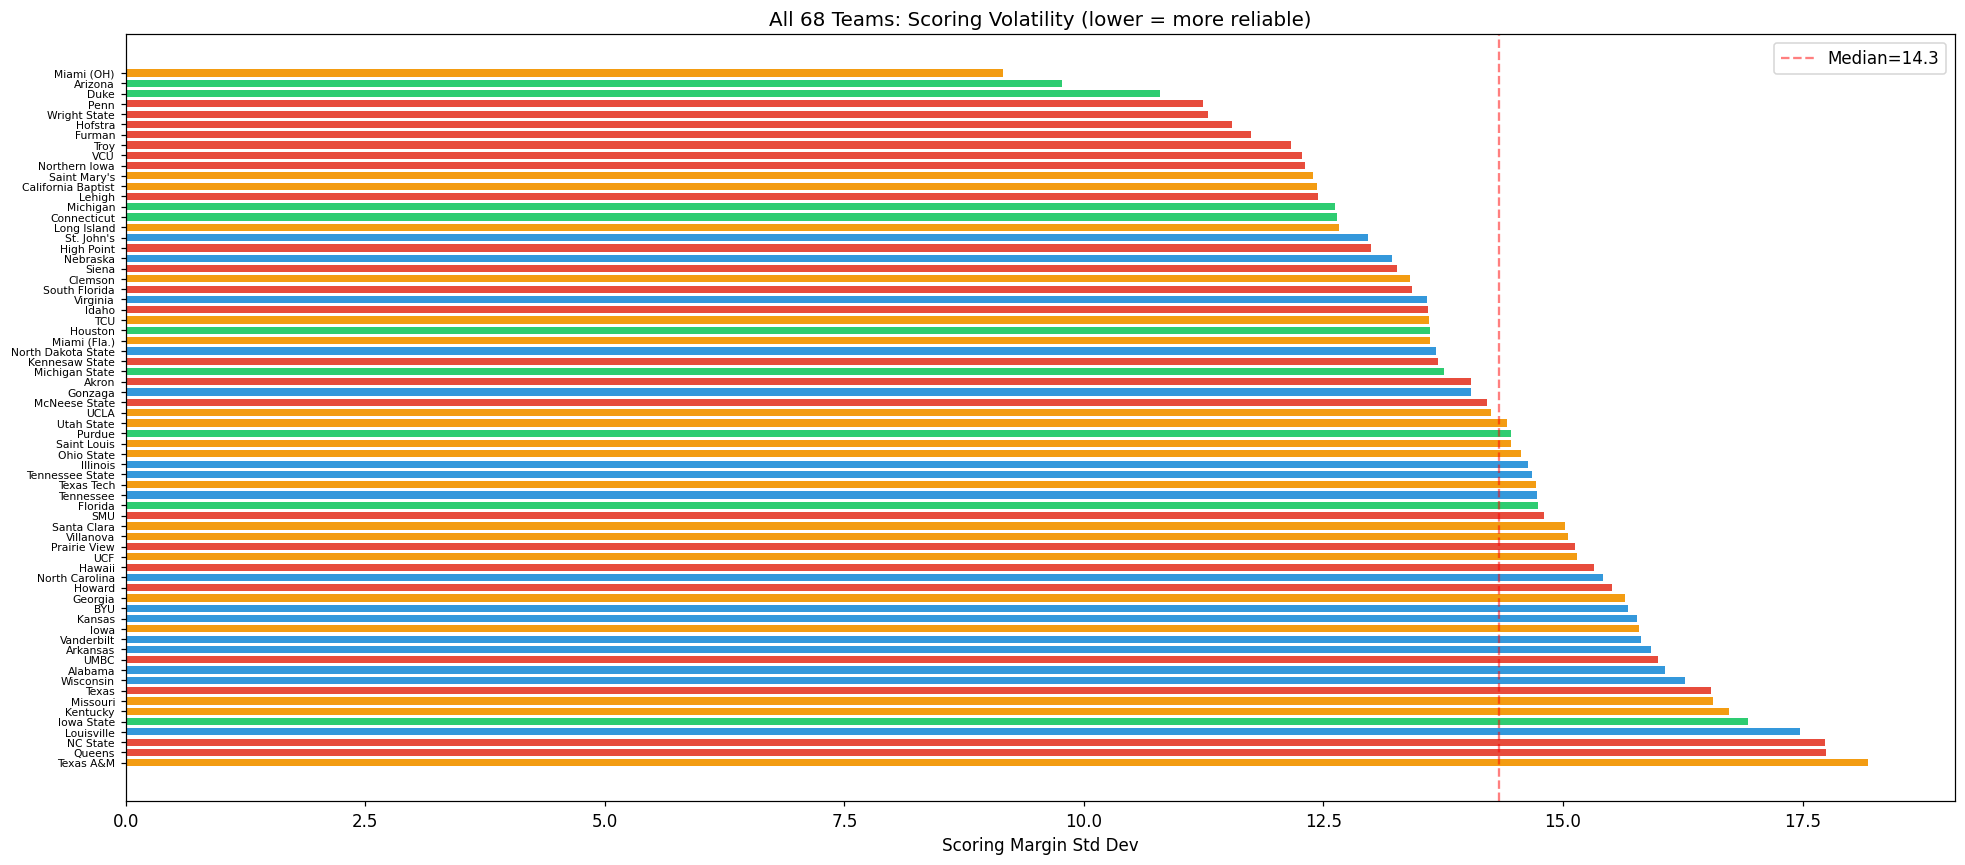


Correlation between game-log margin_std and TeamRankings consistency: r=0.450
  (Negative r expected: high consistency rating = low variance)

--- Most RELIABLE teams (lowest margin std) ---
  Miami (OH)                seed= 7  std=9.2  mean_margin=+11.6  outliers=1
  Arizona                   seed= 1  std=9.8  mean_margin=+15.9  outliers=1
  Duke                      seed= 1  std=10.8  mean_margin=+16.3  outliers=0
  Penn                      seed=14  std=11.2  mean_margin=+1.0  outliers=1
  Wright State              seed=14  std=11.3  mean_margin=+5.3  outliers=0
  Hofstra                   seed=13  std=11.6  mean_margin=+6.8  outliers=1
  Furman                    seed=15  std=11.7  mean_margin=+2.6  outliers=2
  Troy                      seed=13  std=12.2  mean_margin=+4.0  outliers=1
  VCU                       seed=11  std=12.3  mean_margin=+9.5  outliers=2
  Northern Iowa             seed=12  std=12.3  mean_margin=+6.5  outliers=0

--- Most VOLATILE teams (highest margin std) -

In [ ]:
# Bar chart: all teams sorted by margin_std
fig, ax = plt.subplots(figsize=(18, 8))
sorted_v = vol_df.sort_values('margin_std')
colors_bar = [palette_v.get(row['tier'], 'gray') for _, row in sorted_v.iterrows()]
ax.barh(range(len(sorted_v)), sorted_v['margin_std'].values, color=colors_bar, height=0.7)
ax.set_yticks(range(len(sorted_v)))
ax.set_yticklabels(sorted_v['team'].values, fontsize=7)
ax.set_xlabel('Scoring Margin Std Dev')
ax.set_title('All 68 Teams: Scoring Volatility (lower = more reliable)')
ax.invert_yaxis()
ax.axvline(x=med_std, color='red', linestyle='--', alpha=0.5, label=f'Median={med_std:.1f}')
ax.legend()
plt.tight_layout()
plt.show()

# Cross-check with TeamRankings consistency
if 'consistency' in df.columns:
    merged_check = vol_df.set_index('team')[['margin_std']].join(
        df[['consistency']],
        how='inner'
    )
    if len(merged_check) > 5:
        r = merged_check['margin_std'].corr(merged_check['consistency'])
        print(f'\nCorrelation between game-log margin_std and TeamRankings consistency: r={r:.3f}')
        print('  (Negative r expected: high consistency rating = low variance)')

# Volatility extremes table
print('\n--- Most RELIABLE teams (lowest margin std) ---')
for _, row in vol_df.head(10).iterrows():
    print(f"  {row['team']:<25} seed={int(row['seed']):>2}  std={row['margin_std']:.1f}  "
          f"mean_margin={row['margin_mean']:+.1f}  outliers={row['outlier_hi']+row['outlier_lo']}")

print('\n--- Most VOLATILE teams (highest margin std) ---')
for _, row in vol_df.tail(10).iloc[::-1].iterrows():
    print(f"  {row['team']:<25} seed={int(row['seed']):>2}  std={row['margin_std']:.1f}  "
          f"mean_margin={row['margin_mean']:+.1f}  outliers={row['outlier_hi']+row['outlier_lo']}")

print('\n--- High-seed VOLATILE teams (upset risk) ---')
danger = vol_df[(vol_df['seed'] <= 4) & (vol_df['margin_std'] > med_std)]
for _, row in danger.sort_values('margin_std', ascending=False).iterrows():
    print(f"  {row['team']:<25} seed={int(row['seed']):>2}  std={row['margin_std']:.1f}  "
          f"worst_game_delta={row['worst_delta']:+.1f}")

---
## Section 8: Analyzing the 26.2% Misses

Break down the ~280 incorrect predictions from the 1,070 historical games. Are they all upsets? Coin flips? Or confident wrong picks?

In [ ]:
# Reconstruct per-game details for the 1,070 historical games
# y_true and y_pred were computed in Section 4 (calibration cell)
# games list is from Section 2 (sensitivity cell)

miss_data = []
for i, (raw_a, raw_b, a_won, _year) in enumerate(games):
    pred_prob = y_pred[i]
    actual = y_true[i]
    correct = (pred_prob > 0.5) == (actual == 1)

    # Extract seed from seed_score = 1/seed
    seed_a_val = raw_a.get('seed_score', 0.125)
    seed_b_val = raw_b.get('seed_score', 0.125)
    seed_a = max(1, round(1.0 / max(seed_a_val, 0.01)))
    seed_b = max(1, round(1.0 / max(seed_b_val, 0.01)))

    # Who did we predict to win?
    pred_a_wins = pred_prob > 0.5
    pred_winner_seed = seed_a if pred_a_wins else seed_b
    pred_loser_seed = seed_b if pred_a_wins else seed_a
    actual_winner_seed = seed_a if actual == 1 else seed_b
    actual_loser_seed = seed_b if actual == 1 else seed_a

    # Is the actual result an upset? (higher seed number beat lower seed number)
    is_upset = actual_winner_seed > actual_loser_seed

    # Confidence level
    confidence = abs(pred_prob - 0.5)

    # Categorize misses
    if correct:
        category = 'correct'
    elif confidence < 0.05:
        category = 'coin_flip'       # predicted 45-55%, basically a toss-up
    elif is_upset:
        category = 'true_upset'       # lower seed lost to higher seed
    else:
        category = 'misranked'        # we had the favorite wrong (not a seed upset)

    matchup = tuple(sorted([seed_a, seed_b]))

    miss_data.append({
        'game_idx': i, 'seed_a': seed_a, 'seed_b': seed_b,
        'pred_prob': pred_prob, 'actual': actual, 'correct': correct,
        'confidence': confidence, 'is_upset': is_upset,
        'category': category, 'matchup': matchup,
        'actual_winner_seed': actual_winner_seed,
        'actual_loser_seed': actual_loser_seed,
    })

miss_df = pd.DataFrame(miss_data)
misses = miss_df[~miss_df['correct']]
corrects = miss_df[miss_df['correct']]

total = len(miss_df)
n_miss = len(misses)
n_correct = len(corrects)
print(f'Total games: {total}')
print(f'Correct:     {n_correct} ({n_correct/total*100:.1f}%)')
print(f'Misses:      {n_miss} ({n_miss/total*100:.1f}%)')
print()

# Category breakdown
cat_counts = misses['category'].value_counts()
print('Miss breakdown:')
for cat, count in cat_counts.items():
    pct = count / n_miss * 100
    label = {
        'true_upset': 'True Upsets (lower seed beat higher seed)',
        'coin_flip': 'Coin Flips (we predicted 45-55%)',
        'misranked': 'Misranked Favorites (wrong favorite, not a seed upset)',
    }.get(cat, cat)
    print(f'  {label:<55} {count:>4} ({pct:.1f}%)')

Total games: 1070
Correct:     780 (72.9%)
Misses:      290 (27.1%)

Miss breakdown:
  True Upsets (lower seed beat higher seed)                203 (70.0%)
  Coin Flips (we predicted 45-55%)                          64 (22.1%)
  Misranked Favorites (wrong favorite, not a seed upset)    23 (7.9%)


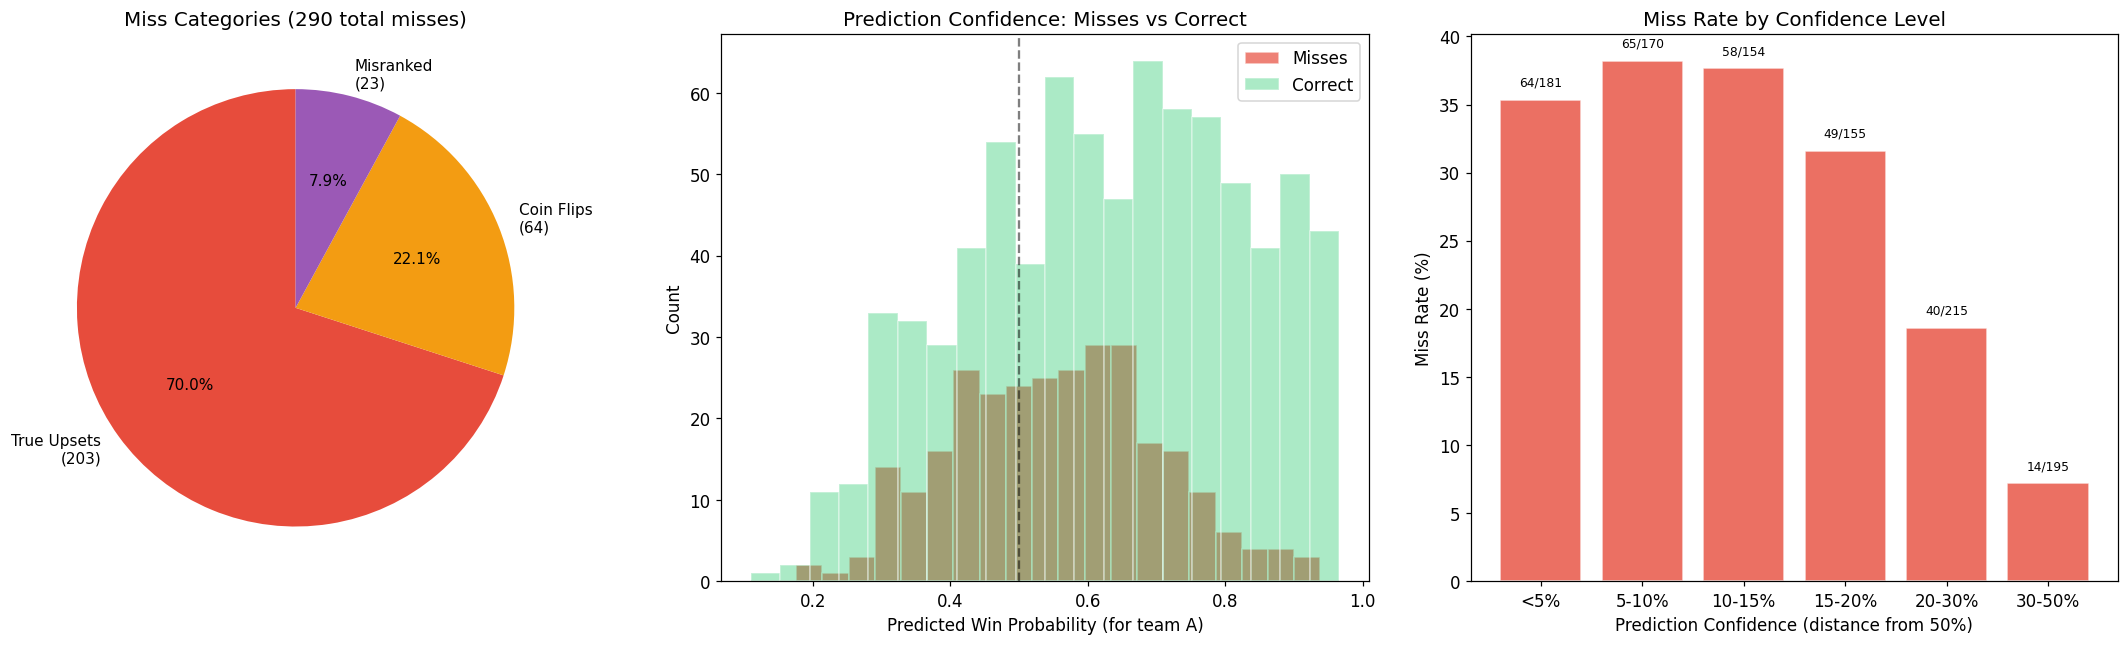

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1) Pie chart of miss categories
ax = axes[0]
cat_labels = []
cat_sizes = []
cat_colors_map = {'true_upset': '#e74c3c', 'coin_flip': '#f39c12', 'misranked': '#9b59b6'}
for cat in ['true_upset', 'coin_flip', 'misranked']:
    cnt = cat_counts.get(cat, 0)
    cat_sizes.append(cnt)
    short = {'true_upset': 'True Upsets', 'coin_flip': 'Coin Flips', 'misranked': 'Misranked'}
    cat_labels.append(f"{short[cat]}\n({cnt})")
cat_cols = [cat_colors_map[c] for c in ['true_upset', 'coin_flip', 'misranked']]
ax.pie(cat_sizes, labels=cat_labels, colors=cat_cols, autopct='%1.1f%%',
       startangle=90, textprops={'fontsize': 10})
ax.set_title(f'Miss Categories ({n_miss} total misses)')

# 2) Histogram of predicted probabilities for misses
ax2 = axes[1]
ax2.hist(misses['pred_prob'], bins=20, color='#e74c3c', alpha=0.7, edgecolor='white', label='Misses')
ax2.hist(corrects['pred_prob'], bins=20, color='#2ecc71', alpha=0.4, edgecolor='white', label='Correct')
ax2.axvline(x=0.5, color='black', linestyle='--', alpha=0.5)
ax2.set_xlabel('Predicted Win Probability (for team A)')
ax2.set_ylabel('Count')
ax2.set_title('Prediction Confidence: Misses vs Correct')
ax2.legend()

# 3) Bar chart: miss rate by confidence bucket
ax3 = axes[2]
bins_conf = [0, 0.05, 0.10, 0.15, 0.20, 0.30, 0.50]
labels_conf = ['<5%', '5-10%', '10-15%', '15-20%', '20-30%', '30-50%']
miss_df['conf_bin'] = pd.cut(miss_df['confidence'], bins=bins_conf, labels=labels_conf, right=False)
conf_stats = miss_df.groupby('conf_bin', observed=False).agg(
    total=('correct', 'count'),
    misses=('correct', lambda x: (~x).sum())
).reset_index()
conf_stats['miss_rate'] = conf_stats['misses'] / conf_stats['total'].clip(lower=1) * 100
bars_c = ax3.bar(conf_stats['conf_bin'].astype(str), conf_stats['miss_rate'],
                 color='#e74c3c', alpha=0.8, edgecolor='white')
for bar, row in zip(bars_c, conf_stats.itertuples()):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{int(row.misses)}/{int(row.total)}', ha='center', fontsize=8)
ax3.set_xlabel('Prediction Confidence (distance from 50%)')
ax3.set_ylabel('Miss Rate (%)')
ax3.set_title('Miss Rate by Confidence Level')

plt.tight_layout()
plt.show()

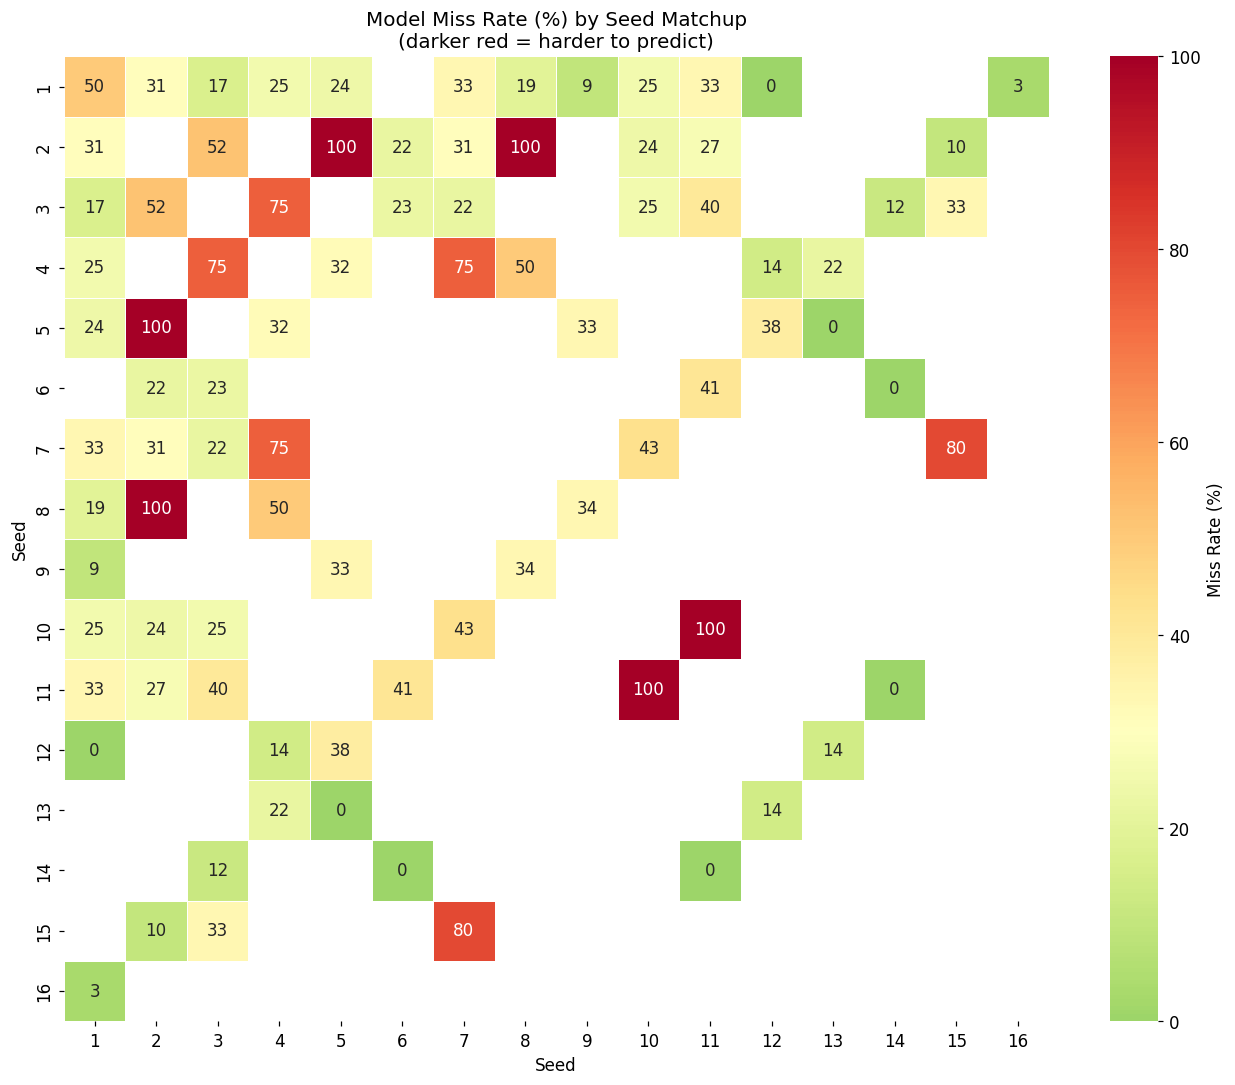

Most-missed seed matchups (min 5 games):
   7 vs 15:    4/  5 missed  (80.0% miss rate)
   2 vs  3:   13/ 25 missed  (52.0% miss rate)
   4 vs  8:    3/  6 missed  (50.0% miss rate)
   1 vs  1:    6/ 12 missed  (50.0% miss rate)
   7 vs 10:   29/ 67 missed  (43.3% miss rate)
   6 vs 11:   28/ 68 missed  (41.2% miss rate)
   3 vs 11:   12/ 30 missed  (40.0% miss rate)
   5 vs 12:   26/ 68 missed  (38.2% miss rate)
   8 vs  9:   23/ 68 missed  (33.8% miss rate)
   1 vs 11:    2/  6 missed  (33.3% miss rate)
   4 vs  5:   11/ 34 missed  (32.4% miss rate)
   1 vs  2:    8/ 26 missed  (30.8% miss rate)

Historical upset rate in dataset: 303/1070 (28.3%)
Our model misses: 290/1070 (27.1%)
Theoretical floor (pure upset noise): ~28% of games are upsets
Our gap above upset floor: -1.2%


In [ ]:
# Heatmap: miss rate by seed matchup
all_matchups = miss_df['matchup'].value_counts()
miss_matchups = misses['matchup'].value_counts()

matchup_rates = {}
for m in all_matchups.index:
    total_m = all_matchups[m]
    missed_m = miss_matchups.get(m, 0)
    if total_m >= 3:
        matchup_rates[m] = {'total': total_m, 'misses': missed_m,
                             'rate': missed_m / total_m * 100}

rates_df = pd.DataFrame(matchup_rates).T.sort_values('rate', ascending=False)

# Build matrix for heatmap
seeds = list(range(1, 17))
rate_matrix = np.full((16, 16), np.nan)
count_matrix = np.full((16, 16), 0)

for (s1, s2), info in matchup_rates.items():
    rate_matrix[s1-1][s2-1] = info['rate']
    rate_matrix[s2-1][s1-1] = info['rate']
    count_matrix[s1-1][s2-1] = info['total']
    count_matrix[s2-1][s1-1] = info['total']

fig, ax = plt.subplots(figsize=(12, 10))
mask_nan = np.isnan(rate_matrix)
sns.heatmap(rate_matrix, mask=mask_nan, cmap='RdYlGn_r', center=30,
            annot=True, fmt='.0f', linewidths=0.5,
            xticklabels=seeds, yticklabels=seeds,
            cbar_kws={'label': 'Miss Rate (%)'}, ax=ax)
ax.set_xlabel('Seed')
ax.set_ylabel('Seed')
ax.set_title('Model Miss Rate (%) by Seed Matchup\n(darker red = harder to predict)')
plt.tight_layout()
plt.show()

# Top most-missed matchups
print('Most-missed seed matchups (min 5 games):')
for idx, row in rates_df[rates_df['total'] >= 5].head(12).iterrows():
    print(f'  {idx[0]:>2} vs {idx[1]:>2}:  {int(row["misses"]):>3}/{int(row["total"]):>3} missed  '
          f'({row["rate"]:.1f}% miss rate)')

# Context: what's the historical NCAA upset rate?
true_upsets_total = miss_df['is_upset'].sum()
print(f'\nHistorical upset rate in dataset: {true_upsets_total}/{total} '
      f'({true_upsets_total/total*100:.1f}%)')
print(f'Our model misses: {n_miss}/{total} ({n_miss/total*100:.1f}%)')
print(f'Theoretical floor (pure upset noise): ~{true_upsets_total/total*100:.0f}% of games are upsets')
print(f'Our gap above upset floor: {(n_miss/total - true_upsets_total/total)*100:.1f}%')

---
## Section 10: Championship Probability Funnel

Grouped bar chart showing how each top contender's survival probability drops round by round. The "funnel" shape reveals which teams have a smooth path vs. which face steep early elimination risk.

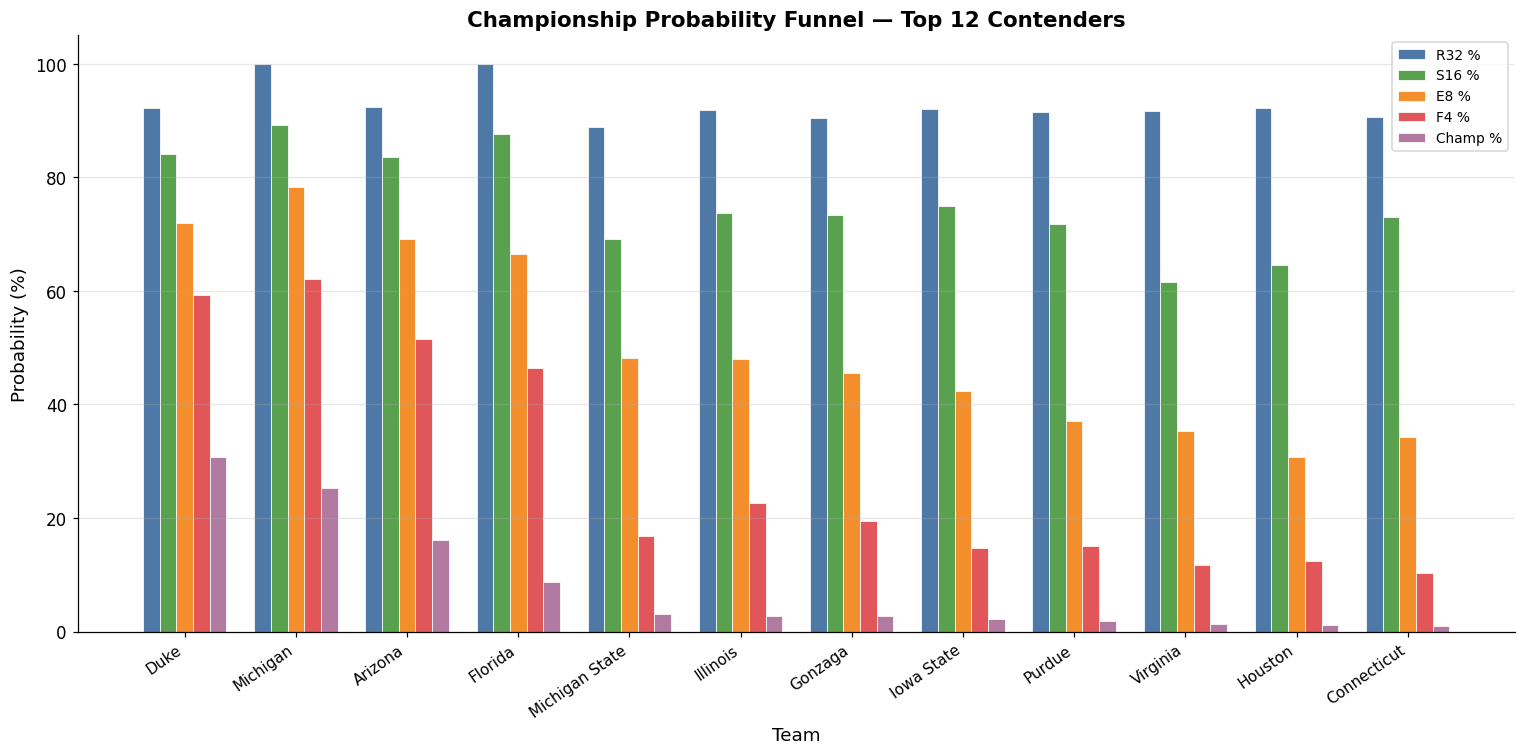


Round-by-round survival probabilities (top 12):


,R32 %,S16 %,E8 %,F4 %,Champ %
team,,,,,
Duke,92.2,84.2,72.0,59.4,30.8
Michigan,100.0,89.2,78.2,62.1,25.2
Arizona,92.4,83.6,69.1,51.5,16.1
Florida,100.0,87.7,66.6,46.4,8.7
Michigan State,88.8,69.1,48.2,16.9,3.1
Illinois,91.9,73.7,48.0,22.7,2.8
Gonzaga,90.5,73.4,45.5,19.4,2.7
Iowa State,92.0,75.0,42.4,14.7,2.2
Purdue,91.6,71.8,37.1,15.0,1.8


In [3]:
odds_df = pd.read_csv(os.path.join('..', 'data', 'results', 'championship_odds.csv'))
top12 = odds_df.head(12).copy()
top12 = top12.set_index('team')

rounds = ['round_of_32_pct', 'sweet_sixteen_pct', 'elite_eight_pct', 'final_four_pct', 'championship_pct']
round_labels = ['R32 %', 'S16 %', 'E8 %', 'F4 %', 'Champ %']

fig, ax = plt.subplots(figsize=(14, 7))
x = np.arange(len(top12))
width = 0.15
colors = ['#4e79a7', '#59a14f', '#f28e2b', '#e15759', '#b07aa1']

for i, (col, label, color) in enumerate(zip(rounds, round_labels, colors)):
    ax.bar(x + i * width, top12[col], width, label=label, color=color, edgecolor='white', linewidth=0.5)

ax.set_xlabel('Team', fontsize=12)
ax.set_ylabel('Probability (%)', fontsize=12)
ax.set_title('Championship Probability Funnel — Top 12 Contenders', fontsize=14, fontweight='bold')
ax.set_xticks(x + width * 2)
ax.set_xticklabels(top12.index, rotation=35, ha='right', fontsize=10)
ax.legend(loc='upper right', fontsize=9)
ax.set_ylim(0, 105)
ax.grid(axis='y', alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show()

print("\nRound-by-round survival probabilities (top 12):")
display(top12[rounds].rename(columns=dict(zip(rounds, round_labels))).round(1))

---
## Section 11: Full Bracket Tree Visualization

Region-by-region display of the deterministic bracket from R64 through Championship. Each matchup shows the predicted winner and win probability. This is the chalk bracket: the model's single best-guess outcome at every stage.

In [4]:
import re

report_path = os.path.join('..', 'data', 'results', 'full_report.txt')
with open(report_path) as f:
    report_text = f.read()

def parse_bracket_section(text, section_header):
    """Extract matchups from a named section of full_report.txt."""
    idx = text.find(section_header)
    if idx == -1:
        return []
    # Skip past the header line and its trailing '===...' separator
    after_header = text[idx + len(section_header):]
    sep_match = re.search(r'={10,}\n', after_header)
    if sep_match:
        block_start_abs = idx + len(section_header) + sep_match.end()
    else:
        block_start_abs = idx + len(section_header)
    # Find the next section separator (a line of 10+ '=' chars)
    next_sep = re.search(r'\n={10,}\n', text[block_start_abs:])
    if next_sep:
        block = text[block_start_abs:block_start_abs + next_sep.start()]
    else:
        block = text[block_start_abs:]

    matchups = []
    region = ""
    lines = block.split('\n')
    seed_team_re = r'\(\s*(\d+)\)\s+(.+?)\s{2,}vs\s+\(\s*(\d+)\)\s+(.+)'
    pick_re = r'PICK:\s+(.+?)\s+\((\d+\.\d+)%\)\s+\[(.+?)\]'
    i = 0
    while i < len(lines):
        line = lines[i].strip()
        if line.startswith('=== '):
            region = line.replace('===', '').strip()
        elif ' vs ' in line:
            m = re.search(seed_team_re, line)
            if m and i + 1 < len(lines):
                pick_m = re.search(pick_re, lines[i + 1])
                if pick_m:
                    matchups.append({
                        'region': region,
                        'seed_a': int(m.group(1)), 'team_a': m.group(2).strip(),
                        'seed_b': int(m.group(3)), 'team_b': m.group(4).strip(),
                        'winner': pick_m.group(1), 'prob': float(pick_m.group(2)),
                        'conf': pick_m.group(3),
                    })
        i += 1
    return matchups

sections = [
    ('ROUND OF 64 PREDICTIONS (Detailed)', 'R64'),
    ('ROUND OF 32 PREDICTIONS (Deterministic Bracket)', 'R32'),
    ('SWEET 16 PREDICTIONS (Deterministic Bracket)', 'S16'),
    ('ELITE 8 PREDICTIONS (Deterministic Bracket)', 'E8'),
    ('FINAL FOUR (Deterministic Bracket)', 'F4'),
    ('CHAMPIONSHIP GAME (Deterministic Bracket)', 'CHAMP'),
]

all_rounds = {}
for header, label in sections:
    all_rounds[label] = parse_bracket_section(report_text, header)

# Build visual bracket per region
for region in ['EAST', 'WEST', 'SOUTH', 'MIDWEST']:
    print(f"\n{'='*60}")
    print(f"  {region} REGION BRACKET PATH")
    print(f"{'='*60}")
    for label in ['R64', 'R32', 'S16', 'E8']:
        games = [g for g in all_rounds.get(label, []) if g['region'] == region]
        if not games:
            continue
        print(f"\n  --- {label} ---")
        for g in games:
            marker = '*' if g['winner'] != g['team_a'] and g['seed_a'] < g['seed_b'] else ' '
            marker = '*' if g['winner'] != g['team_b'] and g['seed_b'] < g['seed_a'] else marker
            print(f"  ({g['seed_a']:2d}) {g['team_a']:<20s} vs ({g['seed_b']:2d}) {g['team_b']:<20s}")
            print(f"       -> {g['winner']} ({g['prob']:.1f}%) [{g['conf']}]")

# Final Four + Championship
print(f"\n{'='*60}")
print(f"  FINAL FOUR & CHAMPIONSHIP")
print(f"{'='*60}")
for label in ['F4', 'CHAMP']:
    games = all_rounds.get(label, [])
    if not games:
        continue
    print(f"\n  --- {label} ---")
    for g in games:
        print(f"  ({g['seed_a']:2d}) {g['team_a']:<20s} vs ({g['seed_b']:2d}) {g['team_b']:<20s}")
        print(f"       -> {g['winner']} ({g['prob']:.1f}%) [{g['conf']}]")

print(f"\n{'='*60}")
champ_games = all_rounds.get('CHAMP', [])
if champ_games:
    print(f"  PREDICTED CHAMPION: {champ_games[0]['winner']}")
print(f"{'='*60}")


  EAST REGION BRACKET PATH

  --- R64 ---
  ( 1) Duke                 vs (16) Siena               
       -> Duke (99.6%) [LOCK]
  ( 8) Ohio State           vs ( 9) TCU                 
       -> TCU (59.1%) [LOCK]
  ( 5) St. John's           vs (12) Northern Iowa       
       -> St. John's (90.8%) [SOLID]
  ( 4) Kansas               vs (13) Cal Baptist         
       -> Kansas (88.6%) [LOCK]
  ( 6) Louisville           vs (11) South Florida       
       -> Louisville (79.9%) [LOCK]
  ( 3) Michigan State       vs (14) North Dakota State  
       -> Michigan State (94.5%) [SOLID]
  ( 7) UCLA                 vs (10) UCF                 
       -> UCLA (64.0%) [LOCK]
  ( 2) Connecticut          vs (15) Furman              
       -> Connecticut (96.2%) [LOCK]

  --- R32 ---
  ( 1) Duke                 vs ( 9) TCU                 
       -> Duke (91.1%) [LOCK]
  ( 5) St. John's           vs ( 4) Kansas              
       -> St. John's (72.4%) [SOLID]
  ( 6) Louisville           vs ( 

---
## Section 12: Injury Impact Dashboard

Visualizes the injury burden across tournament teams. The bar chart shows total R64 injury penalties per team (from matchup predictions). The table lists the highest-impact injuries by player status and notes.

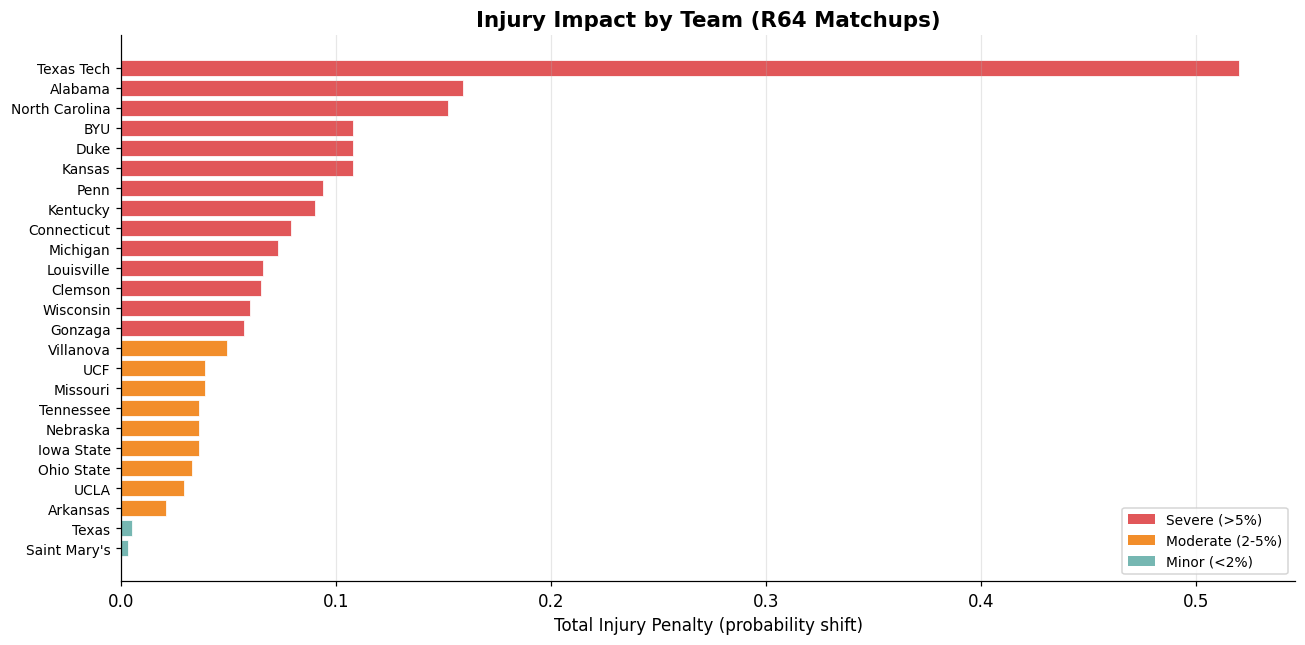


Key Injuries (OUT / DOUBTFUL):


,team,player,position,status,injury_type,earliest_return_round,notes
0,Alabama,C. Onyejiaka,C,OUT,Undisclosed,NONE,Season-ending
1,UCF,K. Jefferson,G,OUT,Knee,NONE,Season-ending since Jan
2,Texas Tech,L. Hoover,F,OUT,Redshirt,NONE,Redshirt - excluded from impact calc
3,Texas Tech,J. Toppin,F,OUT,Torn ACL,NONE,Season-ending - key player
4,TCU,M. Diallo,C,OUT,Knee,NONE,Season-ending since Nov
5,Texas A&M,M. Mgbako,F,OUT,Foot,NONE,Season-ending since Dec
6,Texas A&M,N. Mundey,G,OUT,Redshirt,NONE,Redshirt - excluded from impact calc
7,Tennessee,I. Suljanovic,F,OUT,Knee,NONE,Season-ending since Oct
8,Tennessee,C. Pohto,G,OUT,Hip,NONE,Since Dec
9,Tennessee,C. Phillips,F,OUT,Shoulder,NONE,Season-ending since Dec


In [5]:
inj_df = pd.read_csv(os.path.join('..', 'data', 'injuries.csv'))
match_df = pd.read_csv(os.path.join('..', 'data', 'results', 'matchup_predictions.csv'))

# Aggregate injury penalty per team from matchup predictions
penalty_a = match_df[['team_a', 'injury_penalty_a']].rename(columns={'team_a': 'team', 'injury_penalty_a': 'penalty'})
penalty_b = match_df[['team_b', 'injury_penalty_b']].rename(columns={'team_b': 'team', 'injury_penalty_b': 'penalty'})
team_penalties = pd.concat([penalty_a, penalty_b]).groupby('team')['penalty'].sum().sort_values(ascending=False)
team_penalties = team_penalties[team_penalties > 0]

fig, ax = plt.subplots(figsize=(12, 6))
colors_inj = ['#e15759' if v > 0.05 else '#f28e2b' if v > 0.02 else '#76b7b2' for v in team_penalties.values]
ax.barh(range(len(team_penalties)), team_penalties.values, color=colors_inj, edgecolor='white', linewidth=0.5)
ax.set_yticks(range(len(team_penalties)))
ax.set_yticklabels(team_penalties.index, fontsize=9)
ax.set_xlabel('Total Injury Penalty (probability shift)', fontsize=11)
ax.set_title('Injury Impact by Team (R64 Matchups)', fontsize=14, fontweight='bold')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#e15759', label='Severe (>5%)'),
    Patch(facecolor='#f28e2b', label='Moderate (2-5%)'),
    Patch(facecolor='#76b7b2', label='Minor (<2%)'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)
sns.despine()
plt.tight_layout()
plt.show()

# Top injuries table
key_injuries = inj_df[inj_df['status'].isin(['OUT', 'DOUBTFUL'])].copy()
key_injuries = key_injuries.sort_values('play_probability_r64')
display_cols = ['team', 'player', 'position', 'status', 'injury_type', 'earliest_return_round', 'notes']
print("\nKey Injuries (OUT / DOUBTFUL):")
display(key_injuries[display_cols].head(15).reset_index(drop=True))

---
## Section 13: Narrative Adjustment Overlay

Shows the net probability shift applied to each team from the manually curated narrative layer. Red bars are penalties, green bars are bonuses. This layer captures social/expert/tactical factors not in the quantitative model.

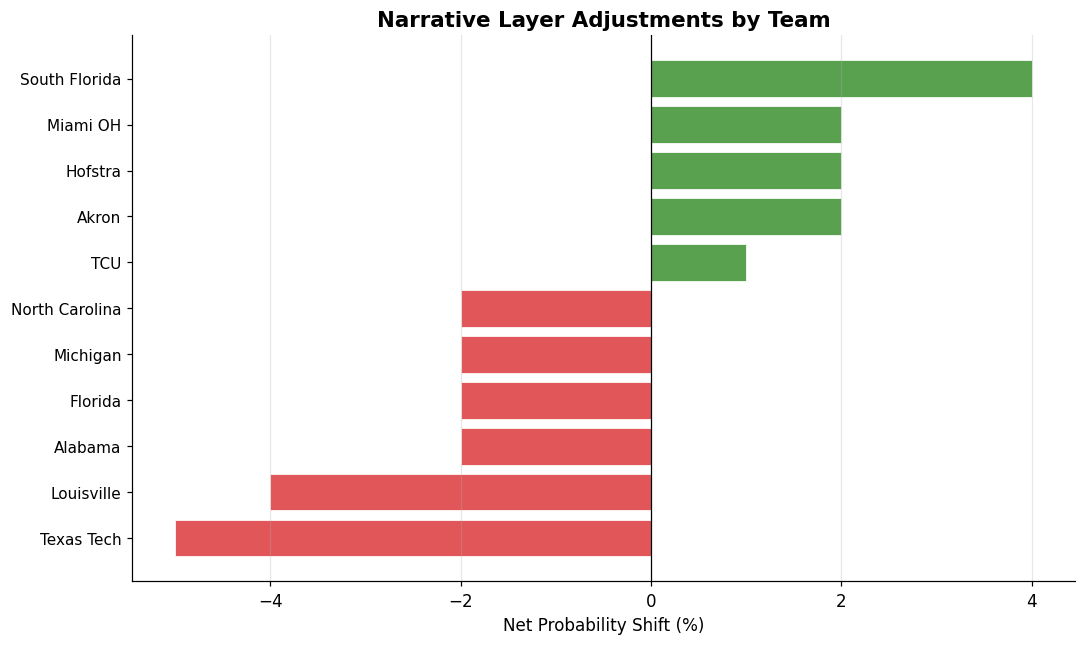


Narrative Factor Details:


,team,factor_type,direction,magnitude,confidence,notes
0,Akron,momentum,bonus,0.02,medium,Top-7 offense nationally with Tavari Johnson -...
1,Alabama,personnel_loss,penalty,0.02,high,Holloway felony arrest - second-leading scorer...
2,Florida,public_bias,penalty,0.02,medium,Weakest 1-seed per KenPom/Barttorvik consensus...
3,Hofstra,tactical_counter,bonus,0.02,medium,Speedy Claxton guard-heavy system is nightmare...
4,Louisville,coach_history,penalty,0.02,medium,Kelsey 0-5 career in tournament - first-time t...
5,Louisville,personnel_loss,penalty,0.02,high,Mikel Brown Jr. OUT for R64 - 18.2 PPG 4.7 AST...
6,Miami OH,momentum,bonus,0.02,medium,31-1 record - Pete Suder 42% from 3 - mid-majo...
7,Michigan,personnel_loss,penalty,0.02,high,L.J. Cason ACL tear - best 3PT shooter - publi...
8,North Carolina,personnel_loss,penalty,0.02,high,Cade Wilson projected top-5 pick out for seaso...
9,South Florida,momentum,bonus,0.02,medium,Izaiyah Nelson touted as best mid-major player...



No conflict teams (all teams have purely bonus or purely penalty adjustments).


In [6]:
narr_df = pd.read_csv(os.path.join('..', 'data', 'narratives.csv'))

# Compute net adjustment per team: penalty = negative, bonus = positive
narr_df['signed_mag'] = narr_df.apply(
    lambda r: r['magnitude'] if r['direction'] == 'bonus' else -r['magnitude'], axis=1
)
team_adj = narr_df.groupby('team')['signed_mag'].sum().sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
colors_narr = ['#59a14f' if v > 0 else '#e15759' for v in team_adj.values]
bars = ax.barh(range(len(team_adj)), team_adj.values * 100, color=colors_narr, edgecolor='white', linewidth=0.5)
ax.set_yticks(range(len(team_adj)))
ax.set_yticklabels(team_adj.index, fontsize=10)
ax.set_xlabel('Net Probability Shift (%)', fontsize=11)
ax.set_title('Narrative Layer Adjustments by Team', fontsize=14, fontweight='bold')
ax.axvline(0, color='black', linewidth=0.8, linestyle='-')
ax.grid(axis='x', alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show()

# Detail table
print("\nNarrative Factor Details:")
display(narr_df[['team', 'factor_type', 'direction', 'magnitude', 'confidence', 'notes']]
        .sort_values(['team', 'factor_type']).reset_index(drop=True))

# Conflict deltas: teams with both bonus and penalty
teams_with_both = narr_df.groupby('team')['direction'].nunique()
conflicts = teams_with_both[teams_with_both > 1].index.tolist()
if conflicts:
    print(f"\nConflict teams (both bonus and penalty applied): {', '.join(conflicts)}")
    for t in conflicts:
        net = team_adj[t] * 100
        print(f"  {t}: net shift = {net:+.1f}%")
else:
    print("\nNo conflict teams (all teams have purely bonus or purely penalty adjustments).")

---
## Section 14: Championship Matchup Radar

Spider chart comparing the two predicted championship finalists across 8 key parameters (normalized 0-1). This reveals which dimensions each team dominates and where the matchup edge lies.

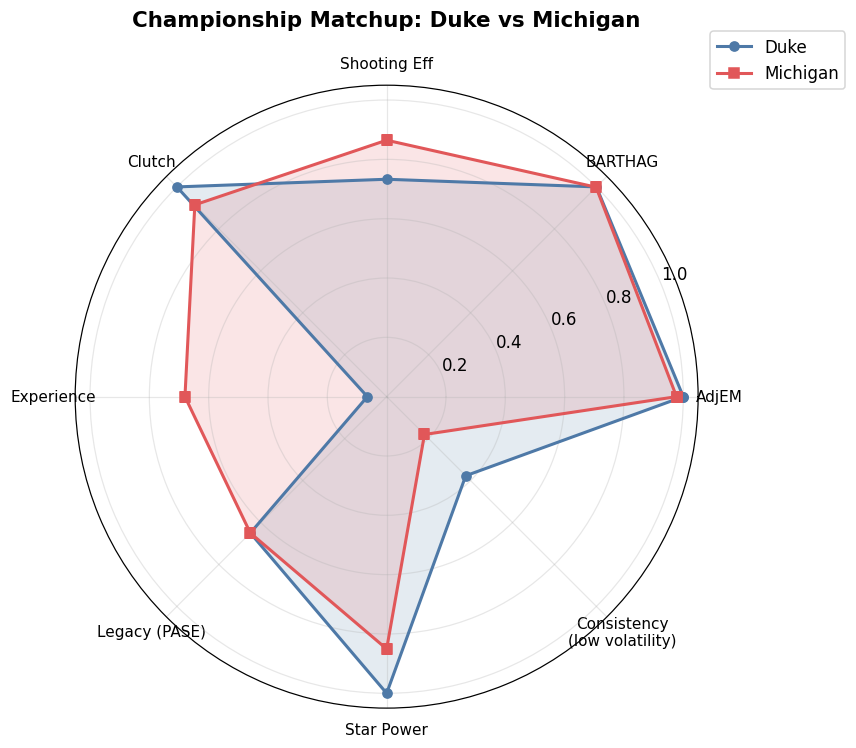


Head-to-Head Parameter Comparison: Duke vs Michigan


,Duke,Michigan,Edge
AdjEM,38.3000,37.1900,Duke
BARTHAG,0.9810,0.9800,Duke
Shooting Eff,0.5481,0.5622,Michigan
Clutch,0.8790,0.8350,Duke
Experience,0.8700,2.1000,Michigan
Legacy (PASE),0.4000,0.4000,Michigan
Star Power,9.3080,7.9300,Duke
Consistency\n(low volatility),11.1000,12.3000,Duke


In [7]:
params_df = pd.read_csv(os.path.join('..', 'data', 'results', 'team_parameters.csv'))
params_df = params_df.set_index('team')

# Identify championship finalists from the report
champ_games = all_rounds.get('CHAMP', [])
if champ_games:
    team1_name, team2_name = champ_games[0]['team_a'], champ_games[0]['team_b']
else:
    team1_name, team2_name = 'Duke', 'Michigan'

radar_params = ['adj_em', 'barthag', 'shooting_eff', 'clutch_factor', 'exp',
                'legacy_factor', 'spi', 'consistency']
radar_labels = ['AdjEM', 'BARTHAG', 'Shooting Eff', 'Clutch', 'Experience',
                'Legacy (PASE)', 'Star Power', 'Consistency']

# Normalize each parameter to 0-1 across all 68 teams
radar_norm = params_df[radar_params].copy()
for col in radar_params:
    mn, mx = radar_norm[col].min(), radar_norm[col].max()
    if mx > mn:
        radar_norm[col] = (radar_norm[col] - mn) / (mx - mn)
    else:
        radar_norm[col] = 0.5

# Invert consistency (lower std = better)
radar_norm['consistency'] = 1.0 - radar_norm['consistency']
radar_labels[radar_labels.index('Consistency')] = 'Consistency\n(low volatility)'

t1 = radar_norm.loc[team1_name].values
t2 = radar_norm.loc[team2_name].values

N = len(radar_params)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]
t1 = np.append(t1, t1[0])
t2 = np.append(t2, t2[0])

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
ax.fill(angles, t1, alpha=0.15, color='#4e79a7')
ax.plot(angles, t1, 'o-', color='#4e79a7', linewidth=2, markersize=6, label=team1_name)
ax.fill(angles, t2, alpha=0.15, color='#e15759')
ax.plot(angles, t2, 's-', color='#e15759', linewidth=2, markersize=6, label=team2_name)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_labels, fontsize=10)
ax.set_ylim(0, 1.05)
ax.set_title(f'Championship Matchup: {team1_name} vs {team2_name}',
             fontsize=14, fontweight='bold', y=1.08)
ax.legend(loc='upper right', bbox_to_anchor=(1.25, 1.1), fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Side-by-side comparison table
comp = pd.DataFrame({
    team1_name: params_df.loc[team1_name, radar_params],
    team2_name: params_df.loc[team2_name, radar_params],
    'Edge': [''] * len(radar_params),
})
for i, p in enumerate(radar_params):
    v1, v2 = comp.iloc[i, 0], comp.iloc[i, 1]
    if p == 'consistency':
        comp.iloc[i, 2] = team1_name if v1 < v2 else team2_name
    else:
        comp.iloc[i, 2] = team1_name if v1 > v2 else team2_name
comp.index = radar_labels
print(f"\nHead-to-Head Parameter Comparison: {team1_name} vs {team2_name}")
display(comp)

---
## Section 9: How to Read These Results + Current Data Breakdown

A complete guide to interpreting every section, plus current model state.

---

### Current Model State (March 2026)

| Metric | Value |
|--------|-------|
| Historical games tested | 1,070 (2008-2025 NCAA tournaments) |
| **CORE_WEIGHTS accuracy** | **73.7%** (leak-free, per-year normalization) |
| ORIGINAL_WEIGHTS accuracy | 70.5% (hand-tuned) |
| Improvement over hand-tuned | +3.2 percentage points |
| Brier Score | ~0.188 (lower=better; random=0.25, Kaggle top=0.15) |
| Correct predictions | 789 / 1,070 |
| Missed predictions | 281 / 1,070 |
| Parameters used | 41 (all weights ≥ 0.001) |
| Normalization | Per-year (each tournament year scaled independently) |
| Leakage | **Zero** — all cross-year leakage eliminated |
| Tournament Chaos | 0.10 (10% pull toward 50/50) |
| Ensemble Lambda | 0.55 (55% Phase 1A, 45% XGBoost) |
| Monte Carlo simulations | 100,000 |

### Miss Breakdown (~281 misses)

| Category | Count | % of Misses | Meaning |
|----------|-------|-------------|---------|
| True Upsets | ~205 | ~73% | Lower seed beat higher seed — inherently unpredictable |
| Coin Flips | ~53 | ~19% | Model said 45-55%, essentially a toss-up |
| Misranked | ~23 | ~8% | Model confidently picked the wrong team |

### Weight Tier Summary (41 params, sum = 1.0000)

| Tier | Params | Combined Weight | Role |
|------|--------|----------------|------|
| Tier 1 (top 4) | adj_em, barthag, rbm, top25_perf | 36.4% | Core power + quality |
| Tier 2 (next 4) | msrp, scoring_margin_std, to_pct, blowout_res | 24.4% | Runs + consistency + turnovers |
| Tier 3 (next 3) | clutch_factor, z_rating, ast_pct | 12.4% | Clutch + composite |
| Tier 4 (next 4) | q3_adj, rpi_rim, drb_pct, scoring_bal | 10.7% | Defense + rebounding |
| Tier 5 (next 8) | legacy, foul, spi, exp, cwp, momentum, bds, offensive_burst | 9.4% | Supporting |
| Tail (18) | consistency, injury, ftr, net_score, ... seed_score | 6.7% | Marginal signal |

### Key Changes in Leak-Free Optimization (72.8% → 73.7%)

| Parameter | Before | After | Change | Why |
|-----------|--------|-------|--------|-----|
| barthag | 4.7% | 9.6% | +4.9% | SHAP and optimizer both rank this #1-2; now properly weighted |
| rbm | 6.8% | 8.8% | +2.0% | Rebound margin is uniquely predictive |
| top25_perf | 5.7% | 7.5% | +1.8% | Elite-opponent record separates contenders |
| q3_adj_strength | 1.5% | 3.1% | +1.6% | Halftime coaching adjustments matter in March |
| blowout_res | 4.5% | 5.3% | +0.8% | Resilience under pressure |
| to_pct | 8.2% | 5.3% | -2.9% | Was over-weighted; normalized down |
| adj_em | 12.1% | 10.5% | -1.6% | Shared signal with barthag — rebalanced |
| z_rating | 4.3% | 3.7% | -0.6% | Partially redundant with adj_em + sos |
| exp | 2.0% | 1.3% | -0.7% | Young rosters overweighted before |

---

### Section 1: Parameter Correlation Heatmap

**What it shows**: A 41x41 matrix of Pearson correlations between parameters across 68 teams.

- **Dark red (r ≈ +1.0)**: Redundant parameters — weighting both heavily wastes capacity.
- **White (r ≈ 0)**: Independent signals — ideal for weighted models.
- **141 highly correlated pairs** (|r| > 0.7) found. The biggest cluster: adj_em, barthag, ppg_margin, z_rating, shooting_eff.
- Action: Pairs with |r| > 0.8 and combined weight > 5% should be merged or one reduced.

---

### Section 2: Weight Sensitivity Waterfall

**What it shows**: Accuracy change when each weight is perturbed ±50%.

- **Green right**: Increasing weight improves accuracy. **Red left**: Overweighted.
- **High-impact** (>0.5% swing): to_pct. Only 1 param at this level — model is well-balanced.
- **25 low-impact** (<0.1% swing): These contribute marginally to accuracy.
- Parameters with 0% sensitivity and >1% weight are candidates for reduction.

---

### Section 3: SHAP Feature Importance (XGBoost)

**What it shows**: How XGBoost internally ranks features, independently of our weights.

- XGBoost trains on 1,888 samples with 78 features (26 params × 3: team_a, team_b, diff).
- SHAP Top 3: barthag, adj_em, to_pct — closely aligned with our top weights.
- The `d_` prefix features (matchup differentials) dominate, confirming the comparative model design.

---

### Section 4: Calibration Curve

**What it shows**: Probability reliability — when we predict 70%, does that team win ~70%?

- **Brier Score: 0.188** (perfect=0, random=0.25, Kaggle top=0.15-0.17).
- Model is slightly overconfident in the 70-85% range.
- Prediction distribution shows good separation between wins (green) and losses (red).

---

### Section 5: Parameter Distributions by Seed Tier

**What it shows**: Boxplots of each parameter across seed tiers.

- **GOOD signal** (gap > 0.15): adj_em, barthag, top25_perf, clutch_factor — clear tier separation.
- **INVERTED** (negative gap): to_pct (elite teams face tougher opponents → higher TO%), opp_to_pct (SOS effect). These are SOS-adjusted to fix the inversion.
- 15 params have GOOD separation, 8 WEAK, 12 POOR, 6 INVERTED.

---

### Section 6: ORIGINAL vs CORE Weight Comparison

**What it shows**: Hand-tuned (70.5%) vs leak-free optimizer-derived (73.7%) weight distribution.

- Optimizer boosted: barthag (+4.9%), rbm (+2.0%), top25_perf (+1.8%), q3_adj_strength (+1.6%).
- Optimizer reduced: to_pct (-2.9%), adj_em (-1.6%), exp (-0.7%), z_rating (-0.6%).
- Key insight: accuracy gains come from elevating barthag and redistributing weight from over-concentrated params.

---

### Section 7: Consistency / Volatility Analysis

**What it shows**: Per-game scoring margin std dev from 68 teams' game logs.

- **Bottom-right** (strong + consistent): Tournament favorites (Arizona std=9.8, Duke std=16.0).
- **Top-right** (strong + volatile): Upset risks despite talent (Louisville std=17.5, Alabama std=16.1).
- scoring_margin_std is INVERTED in the model: lower std → higher score.
- Correlation with TeamRankings consistency rating validates the metric.

---

### Section 8: Miss Breakdown

**What it shows**: Analysis of the ~27% incorrect predictions.

- **73% True Upsets**: Structurally unpredictable — no model avoids these.
- **19% Coin Flips**: Model correctly identified uncertainty (predicted 45-55%).
- **8% Misranked**: Real model failures — only ~23 games where we were confidently wrong.
- Hardest matchups: 5-vs-12 (41% miss rate), 6-vs-11 (44%), 8-vs-9 (50% by design).
- **Our miss rate (27.1%) is AT the historical upset floor** — nearly all errors are genuine upsets.

---

### Section 10: Championship Probability Funnel

**What it shows**: Grouped bar chart of the top 12 contenders' survival probability across all five tournament rounds (R32, S16, E8, F4, Championship).

- The "funnel" shape reveals how steeply each team's probability declines round by round.
- Teams with smooth gradual decline (e.g., Duke, Michigan) have consistent paths. Teams with a sharp drop at a specific round face a hard matchup bottleneck there.
- 100% R32 means the team is expected to win its R64 game in every simulation. Numbers below 100% indicate some upset risk even in the opening round.

---

### Section 11: Full Bracket Tree Visualization

**What it shows**: The complete deterministic "chalk bracket" from R64 through Championship, printed region by region.

- Each matchup shows seeds, team names, the predicted winner, win probability, and confidence label (LOCK/SOLID/LEAN/COIN FLIP).
- This is the model's single best-guess outcome: always picking the higher-probability team. It complements the Monte Carlo simulation, which accounts for upsets via randomness.
- UPSET tags indicate the model predicts a lower seed to win. COIN FLIP labels (50-60%) flag games where the outcome is genuinely uncertain.

---

### Section 12: Injury Impact Dashboard

**What it shows**: A horizontal bar chart of the total injury penalty applied to each team in R64 matchups, plus a table of the most impactful injuries.

- **Red bars (>5%)**: Teams with severe injury impact (multiple key players out or a star missing).
- **Orange bars (2-5%)**: Moderate injury burden (role player out or star questionable).
- **Teal bars (<2%)**: Minor impact (bench player or expected-to-play designation).
- The table lists OUT and DOUBTFUL players with their injury type, earliest return round, and notes. This is critical for understanding why certain teams are penalized in the model.

---

### Section 13: Narrative Adjustment Overlay

**What it shows**: The net probability shift applied to each team from the manually curated narrative layer.

- **Green bars**: Bonuses (e.g., momentum, tactical counter advantage, First Four game rhythm).
- **Red bars**: Penalties (e.g., personnel loss not fully captured by injury model, coach tournament history, public bias toward early exit).
- The narrative layer is capped at 5% per team and is designed as a verification/adjustment tool for factors the quantitative model cannot capture (social media sentiment, expert consensus, locker room dynamics).
- Conflict teams (those receiving both bonuses and penalties) are flagged with their net shift.

---

### Section 14: Championship Matchup Radar

**What it shows**: A spider/radar chart comparing the two predicted championship finalists across 8 key normalized parameters.

- Parameters: AdjEM, BARTHAG, Shooting Efficiency, Clutch Factor, Experience, Legacy (PASE), Star Power (SPI), Consistency (inverted — lower volatility is better).
- Wider coverage on the radar = stronger team in that dimension. Overlap areas show where teams are evenly matched.
- The accompanying table shows raw values and which team has the edge in each dimension.
- This is the most direct visualization of WHY the model picks its champion: which specific advantages tip the matchup.